In [1]:
import numpy as np
from scipy import optimize
import matplotlib.pyplot as plt
import pandas as pd
from scipy.interpolate import interp1d

# Molar masses (g/mol) of relevant gas species
mu_dict = {'SiO2': 60.08,
            'TiO2': 79.87,
            'Al2O3': 101.96,
            'FeO_star': 71.84,
            'FeO': 71.84,
            'Fe2O3': 159.69,
            'MnO': 70.94,
            'MgO': 40.30,
            'CaO': 56.08,
            'Na2O': 61.98,
            'K2O': 94.20,
            'P2O5': 141.94,
            'S': 32.06,
            'C': 12.01,
            'H': 1.008,
            'O': 16.00,
            'H2O': 18.01528,
            'H2': 2.01588,
            'H2S': 34.08088,
            'CO2': 44.0095,
            'CO': 28.0101,
            'CH4': 16.04246,
            'SO2': 64.066,
            'S2': 64.142
           }

In [2]:
def calc_FeOratio(T, P, fO2, x_dict, T0 = 1673.0):
    # INPUT P IN BARS
    # Convert it to Pa now
    P = P * 1e5 # Pa

    # Table 7 parameters
    a  = 0.196
    b  = 1.1492e4   # K
    c  = -6.675
    d_Al2O3 = -2.243
    d_FeO_star   =  -1.828
    d_CaO   =  3.201
    d_Na2O  =  5.854
    d_K2O   =  6.215
    e  = -3.36
    f  = -7.01e-7      # K Pa^-1
    g  = -1.54e-10     # Pa^-1
    h  =  3.85e-17     # K Pa^-2

    # Composition term without FeO: Σ d_i X_i  (i ≠ FeO)
    comp = (
        d_Al2O3 * x_dict.get("Al2O3", 0.0) +
        d_FeO_star * x_dict.get("FeO_star", 0.0) +
        d_CaO   * x_dict.get("CaO",   0.0) +
        d_Na2O  * x_dict.get("Na2O",  0.0) +
        d_K2O   * x_dict.get("K2O",   0.0)
    )

    # P–T terms
    bracket = 1.0 - (T0 / T) - np.log(T / T0)
    PT_term = (f * (P / T)) + (g * ((T - T0) / T) * P) + (h * (P**2 / T))

    # Full equation
    ratio_Fe2O3_to_FeO = np.exp((a*np.log(fO2)) + (b/T) + c + comp + (e*bracket) + PT_term)

    return ratio_Fe2O3_to_FeO

def calc_CO2_solubility_constant(P, T, x_FeO, x_dict):

    mu_magma = 64.52 # Molar mass of magma in g/mol, based on Mt. Etna basalt
    mu_co3 = 60.01 # Molar mass of CO3 in g/mol

    C_CO2 = 0.14
    B_CO2 = -5.3
    b_CO2 = 15.8
    d_Al2O3 = 3.8
    d_FeO = -16.3
    d_Na2O = 20.1

    NBO_O = (2*(x_dict["K2O"]+x_dict["Na2O"]+x_dict["CaO"]+x_dict["MgO"]+x_FeO-x_dict["Al2O3"]))/ \
        (2*x_dict["SiO2"]+2*x_dict["TiO2"]+3*x_dict["Al2O3"]+x_dict["MgO"]+x_FeO+x_dict["CaO"]+x_dict["Na2O"]+x_dict["K2O"])
    
    extra_term = (d_Al2O3 * x_dict.get("Al2O3", 0.0)/(x_dict["CaO"] + x_dict["K2O"] + x_dict["Na2O"])) + \
                 (d_FeO * (x_FeO + x_dict["MgO"])) +  (d_Na2O * (x_dict["Na2O"] + x_dict["K2O"]))

    S1 = np.log(mu_magma/(mu_co3*1e6)) + (C_CO2*P/T) + B_CO2 + (b_CO2*NBO_O) + extra_term # CO2

    return S1


def calc_H2O_solubility_constant(P, T, x_FeO, x_dict):

    mu_magma = 64.52 # Molar mass of magma in g/mol, based on Mt. Etna basalt
    mu_h2o = 18.01528 # Molar mass of H2O in g

    a_H2O = 0.54
    b_H2O = 1.24
    B_H2O = -2.95
    C_H2O = 0.02

    NBO_O = (2*(x_dict["K2O"]+x_dict["Na2O"]+x_dict["CaO"]+x_dict["MgO"]+x_FeO-x_dict["Al2O3"]))/ \
        (2*x_dict["SiO2"]+2*x_dict["TiO2"]+3*x_dict["Al2O3"]+x_dict["MgO"]+x_FeO+x_dict["CaO"]+x_dict["Na2O"]+x_dict["K2O"])

    S2 = np.log(mu_magma/(mu_h2o*100)) + (C_H2O*P/T) + B_H2O + (b_H2O*NBO_O) # H2O

    return S2

In [3]:
def calc_outgassing(T, mH2O_sat, mCO2_sat, mS_sat, FMQ_sat, alphaG_sat, FeO_star_wt, verbose=False):

    ### Initialize the magma composition

    mass_frac_dict = {
           'SiO2': 47.95 * 1e-2, # wt% * 1e-2
           'TiO2': 1.67 * 1e-2, # wt% * 1e-2
           'Al2O3': 17.32 * 1e-2, # wt% * 1e-2
           'MnO': 0 * 1e-2, # wt% * 1e-2
           'MgO': 5.76 * 1e-2, # wt% * 1e-2
           'CaO': 10.93 * 1e-2, # wt% * 1e-2
           'Na2O': 3.45 * 1e-2, # wt% * 1e-2
           'K2O': 1.99 * 1e-2, # wt% * 1e-2
           'P2O5': 0.51 * 1e-2, # wt% * 1e-2
           'H2O': mH2O_sat, # ppm * 1e-6
            'CO2': mCO2_sat, # ppm * 1e-6
            'S': mS_sat, # ppm * 1e-6
            'FeO_star': FeO_star_wt, # wt% * 1e-2
            'FeO': 0.0, # Placeholder, will be calculated later
            'Fe2O3': 0.0 # Placeholder, will be calculated later
           }

    mu_magma = 1/sum([mass_frac_dict[oxide]/mu_dict[oxide] for oxide in mass_frac_dict.keys()])
    if verbose:
        print("Magma molar mass: ", mu_magma)

    mole_frac_dict = {
        'SiO2':     mass_frac_dict['SiO2']     * mu_magma / mu_dict['SiO2'],
        'TiO2':     mass_frac_dict['TiO2']     * mu_magma / mu_dict['TiO2'],
        'Al2O3':    mass_frac_dict['Al2O3']    * mu_magma / mu_dict['Al2O3'],
        'FeO_star': mass_frac_dict['FeO_star'] * mu_magma / mu_dict['FeO'],
        'FeO':      mass_frac_dict['FeO']      * mu_magma / mu_dict['FeO'],
        'Fe2O3':    mass_frac_dict['Fe2O3']    * mu_magma / mu_dict['Fe2O3'],
        'MnO':      mass_frac_dict['MnO']      * mu_magma / mu_dict['MnO'],
        'MgO':      mass_frac_dict['MgO']      * mu_magma / mu_dict['MgO'],
        'CaO':      mass_frac_dict['CaO']      * mu_magma / mu_dict['CaO'],
        'Na2O':     mass_frac_dict['Na2O']     * mu_magma / mu_dict['Na2O'],
        'K2O':      mass_frac_dict['K2O']      * mu_magma / mu_dict['K2O'],
        'P2O5':     mass_frac_dict['P2O5']     * mu_magma / mu_dict['P2O5'],
        'H2O':      mass_frac_dict['H2O']      * mu_magma / mu_dict['H2O'],
        'CO2':      mass_frac_dict['CO2']      * mu_magma / mu_dict['CO2'],
        'S':        mass_frac_dict['S']        * mu_magma / mu_dict['S'],
    }

    xO_oxides = mole_frac_dict['SiO2']*2 + mole_frac_dict['TiO2']*2 + mole_frac_dict['Al2O3']*3 + \
                mole_frac_dict['MnO'] + mole_frac_dict['MgO'] + mole_frac_dict['CaO'] + \
                mole_frac_dict['Na2O'] + mole_frac_dict['K2O'] + mole_frac_dict['P2O5']*5

    ### Get mole fractions
    xH2O_sat = mole_frac_dict['H2O']
    xCO2_sat = mole_frac_dict['CO2']
    xS_sat   = mole_frac_dict['S']

    ### Equilibrium constants for speciation reactions
    K1 = np.exp(-29755.11319228574/T+6.652127716162998) # H2 + 0.5O2 = H2O
    K2 = np.exp(-33979.12369002451/T+10.418882755464773) # CO + 0.5O2 = CO2
    K3 = np.exp(-96444.47151911151/T+0.22260815074146403) # CH4 + 2O2 = CO2 + 2H2O
    K4 = np.exp(4.35250424e+04/T-8.80403494e+00) # 0.5S2 + O2 = SO2
    K5 = np.exp(1.90560415e+04/T-8.60366131e-01) # H2S + 0.5O2 = 0.5S2 + H2O

    def nan_results():
        nan_arr = np.full_like(np.logspace(3, -5, num=9), np.nan, dtype=float)
        return {
            'P': nan_arr.copy(),
            'H2O': nan_arr.copy(),
            'H2': nan_arr.copy(),
            'CO2': nan_arr.copy(),
            'CO': nan_arr.copy(),
            'CH4': nan_arr.copy(),
            'S2': nan_arr.copy(),
            'SO2': nan_arr.copy(),
            'H2S': nan_arr.copy(),
            'O2': nan_arr.copy(),
            'xCO2': nan_arr.copy(),
            'xH2O': nan_arr.copy(),
            'xS': nan_arr.copy(),
            'alphaG': nan_arr.copy(),
            'FMQ': nan_arr.copy(),
            'xCO2_sat': np.nan,
            'xH2O_sat': np.nan,
            'xS_sat': np.nan,
            'mu_magma': np.nan
        }

    ### Calculate gas-melt composition at saturation

    P_sat = 1000 # bar, The while loop is to converge on P_sat
    max_sat_iter = 200
    for sat_iter in range(max_sat_iter):
        ### Calculate actual fO2 at saturation
        A_fug = 25096.3; B_fug = 8.735; C_fug = 0.11 # FMQ fugacity from VolFe
        log_FMQ_sat = (-A_fug/T+B_fug+C_fug*(P_sat-1)/T)
        fO2_sat = 10**(log_FMQ_sat+FMQ_sat)

        ### Calculate FeO and Fe2O3 mole fractions at saturation
        Fe2O3_FeO_ratio = calc_FeOratio(T, P_sat, fO2_sat, mole_frac_dict)
        x_FeO_sat = mole_frac_dict["FeO_star"] / (1 + 2*Fe2O3_FeO_ratio)
        x_Fe2O3_sat = mole_frac_dict["FeO_star"] /((1/Fe2O3_FeO_ratio) + 2)

        ### Calculate sulfur solubility at saturation
        m_FeO_pct = 100 * x_FeO_sat * mu_dict['FeO'] / mu_magma # Convert mole fraction to wt%
        Cs = (mu_magma/mu_dict['S'])*1e-6*0.0003*(100 - m_FeO_pct)*np.exp(0.21*m_FeO_pct) # Sulfur solubility in melt at saturation in wt fraction

        d_H2O = 2.3; a_CO2 = 1; a_H2O = 0.54 # Constants
        P_CO2_sat = np.exp((np.log(xCO2_sat) - (xH2O_sat * d_H2O) - calc_CO2_solubility_constant(P_sat, T, x_FeO_sat, mole_frac_dict))/a_CO2)
        P_H2O_sat = np.exp((np.log(xH2O_sat) - calc_H2O_solubility_constant(P_sat, T, x_FeO_sat, mole_frac_dict))/a_H2O) ## From Wogan 2020
        # P_H2O_sat = (xH2O_sat**2)/4.6114e-6 ## From VolFe
        P_S2_sat  = (fO2_sat*xS_sat**2)/(Cs**2)

        ### Gas composition at saturation
        P_H2_sat = K1*P_H2O_sat/((fO2_sat)**0.5)
        P_CO_sat = K2*P_CO2_sat/((fO2_sat)**0.5)
        P_CH4_sat = K3*P_CO2_sat*(P_H2O_sat**2)/(fO2_sat**2)
        P_SO2_sat = K4*fO2_sat*(P_S2_sat**0.5)
        P_H2S_sat = (P_S2_sat**0.5)*P_H2O_sat/(K5*(fO2_sat**0.5))

        P_calc = P_CO2_sat + P_H2O_sat + P_S2_sat + P_H2_sat + P_H2S_sat + P_SO2_sat + P_CO_sat + P_CH4_sat
        if not np.isfinite(P_calc) or P_calc <= 0:
            print(f"Warning: Encountered non-physical saturation pressure ({P_calc}). Returning NaNs.")
            return nan_results()
        if abs(P_calc - P_sat) < 1:
            P_sat = P_calc
            break
        P_sat = P_calc
    else:
        if verbose:
            print(f"Warning: Saturation pressure did not converge after {max_sat_iter} iterations. Returning NaNs.")
        return nan_results()

    ### Calculate total elemental abundances at saturation    
    xC_tot = (((P_CO2_sat + P_CO_sat + P_CH4_sat)/P_sat)*alphaG_sat) + ((1 - alphaG_sat)*(xCO2_sat)) # total C
    xH_tot = (((2*P_H2O_sat + 4*P_CH4_sat + 2*P_H2S_sat + 2*P_H2_sat)/P_sat)*alphaG_sat) + ((1 - alphaG_sat)*(2*xH2O_sat)) # total H
    xS_tot = ((2*P_S2_sat + P_SO2_sat + P_H2S_sat)/P_sat)*alphaG_sat + ((1 - alphaG_sat)*xS_sat) # total S
    xO_tot = (((P_H2O_sat + 2*P_SO2_sat + 2*P_CO2_sat + P_CO_sat)/P_sat)*alphaG_sat) + ((1 - alphaG_sat)*(1*xH2O_sat + 2*xCO2_sat + 1*x_FeO_sat + 3*x_Fe2O3_sat + 0*mole_frac_dict["FeO_star"])) # total O


    P_grid = np.logspace(3, -5, num=9) # bar

    P_H2O_arr = np.full_like(P_grid, np.nan, dtype=float); P_H2_arr = np.full_like(P_grid, np.nan, dtype=float); P_CO2_arr = np.full_like(P_grid, np.nan, dtype=float); P_CO_arr = np.full_like(P_grid, np.nan, dtype=float)
    P_CH4_arr = np.full_like(P_grid, np.nan, dtype=float); P_SO2_arr = np.full_like(P_grid, np.nan, dtype=float); P_H2S_arr = np.full_like(P_grid, np.nan, dtype=float); P_S2_arr = np.full_like(P_grid, np.nan, dtype=float)
    xCO2_arr = np.full_like(P_grid, np.nan, dtype=float); xH2O_arr = np.full_like(P_grid, np.nan, dtype=float); xS_arr = np.full_like(P_grid, np.nan, dtype=float)
    fO2_arr = np.full_like(P_grid, np.nan, dtype=float); alphaG_arr = np.full_like(P_grid, np.nan, dtype=float); P_check_arr = np.full_like(P_grid, np.nan, dtype=float); FMQ_final_arr = np.full_like(P_grid, np.nan, dtype=float)

    last_success_idx = None

    for i, P in enumerate(P_grid):

        def system(y):

            ln_P_H2O, ln_P_H2, ln_P_CO2, ln_P_CO, ln_P_CH4, ln_P_S2, ln_P_H2S, ln_P_SO2, ln_fO2, ln_xCO2_melt, ln_xH2O_melt, ln_xS_melt, alphaG = y

            ### Gas speciation equation
            eq1 = np.log(K1) + ln_P_H2O - 0.5*ln_fO2 - ln_P_H2 # H2 + 0.5O2 = H2O
            eq2 = np.log(K2) + ln_P_CO2 - 0.5*ln_fO2 - ln_P_CO # CO + 0.5O2 = CO2
            eq3 = np.log(K3) + ln_P_CO2 + 2*ln_P_H2O - 2*ln_fO2 - ln_P_CH4 # CH4 + 2O2 = CO2 + 2H2O
            eq4 = np.log(K4) + ln_fO2 + 0.5*ln_P_S2 - ln_P_SO2  # 0.5S2 + O2 = SO2
            eq5 = np.log(K5) + 0.5*ln_fO2 + ln_P_H2S - 0.5*ln_P_S2 - ln_P_H2O # H2S + 0.5O2 = 0.5S2 + H2O

            ### Melt solubility equations
            ### Calculate FeO and Fe2O3 mole fractions
            Fe2O3_FeO_ratio = calc_FeOratio(T, P, np.exp(ln_fO2), mole_frac_dict)
            x_FeO = mole_frac_dict["FeO_star"] / (1 + 2*Fe2O3_FeO_ratio)
            x_Fe2O3 = mole_frac_dict["FeO_star"] /((1/Fe2O3_FeO_ratio) + 2)
            m_FeO_pct = 100*x_FeO * mu_dict['FeO'] / mu_magma  # Convert mole fraction to wt%
            Cs = (mu_magma/mu_dict['S'])*1e-6*0.0003*(100 - m_FeO_pct)*np.exp(0.21*m_FeO_pct) # assuming this was ppm by mass so converted to ppm by mole

            # Constants and H2
            xH2_melt = np.exp(1.28*ln_P_H2 + np.log(mu_magma*3.4e-7/(2.016*2.7)))

            # Actual solubility equations
            d_H2O = 2.3; a_CO2 = 1; a_H2O = 0.54 # Constants
            eq6 = ((ln_xCO2_melt - (np.exp(ln_xH2O_melt) * d_H2O) - calc_CO2_solubility_constant(P, T, x_FeO, mole_frac_dict))/a_CO2) - ln_P_CO2
            eq7 = ((ln_xH2O_melt - calc_H2O_solubility_constant(P, T, x_FeO, mole_frac_dict))/a_H2O) - ln_P_H2O ## From Wogan 2020
            # eq7 = -ln_P_H2O + 2*ln_xH2O_melt - np.log(4.6114e-6) ## From VolFe
            eq8 = ln_xS_melt + 0.5*ln_fO2 - 0.5*ln_P_S2 - np.log(Cs) # S solubility equation

            ### Conservation of atoms
            eq9 = ((np.exp(ln_P_CO2) + np.exp(ln_P_CO) + np.exp(ln_P_CH4))*alphaG) + (P*(1 - alphaG)*(np.exp(ln_xCO2_melt))) - (P*xC_tot) # total C
            eq10 = ((2*np.exp(ln_P_H2O) + 4*np.exp(ln_P_CH4) + 2*np.exp(ln_P_H2S) + 2*np.exp(ln_P_H2))*alphaG) + (P*(1 - alphaG)*(2*np.exp(ln_xH2O_melt))) - (P*xH_tot) # total H
            eq11 = ((2*np.exp(ln_P_S2) + np.exp(ln_P_SO2) + np.exp(ln_P_H2S))*alphaG) + (P*(1 - alphaG)*np.exp(ln_xS_melt)) - (P*xS_tot) # total S
            eq12 = ((np.exp(ln_P_H2O) + 2*np.exp(ln_P_SO2) + 2*np.exp(ln_P_CO2) + np.exp(ln_P_CO))*alphaG) + (P*(1 - alphaG)*(1*np.exp(ln_xH2O_melt) + 2*np.exp(ln_xCO2_melt) + 1*x_FeO + 3*x_Fe2O3 + 0*mole_frac_dict["FeO_star"])) - (P*xO_tot) # total O

            ### Conservation of total mass
            eq13 = np.exp(ln_P_H2O) + np.exp(ln_P_H2) + np.exp(ln_P_CO2) + np.exp(ln_P_CO) + np.exp(ln_P_CH4) + np.exp(ln_P_S2) + np.exp(ln_P_H2S) + np.exp(ln_P_SO2) - P
            return [eq1, eq2, eq3, eq4, eq5, eq6, eq7, eq8, eq9, eq10, eq11, eq12, eq13]


        ### Build continuation initial guess from the latest successful pressure level.
        eps = np.finfo(float).tiny
        if last_success_idx is None:
            p_ratio = P / P_sat
            init_cond = [np.log(max(P_H2O_sat * p_ratio, eps)), np.log(max(P_H2_sat * p_ratio, eps)), np.log(max(P_CO2_sat * p_ratio, eps)), np.log(max(P_CO_sat * p_ratio, eps)), np.log(max(P_CH4_sat * p_ratio, eps)), np.log(max(P_S2_sat * p_ratio, eps)), 
                        np.log(max(P_H2S_sat * p_ratio, eps)), np.log(max(P_SO2_sat * p_ratio, eps)), np.log(max(fO2_sat, eps)), np.log(max(xCO2_sat, eps)), np.log(max(xH2O_sat, eps)), 
                        np.log(max(xS_sat, eps)), alphaG_sat]
        else:
            p_ref = P_grid[last_success_idx]
            p_ratio = P / p_ref
            alpha_init = alphaG_arr[last_success_idx] if np.isfinite(alphaG_arr[last_success_idx]) else alphaG_sat
            init_cond = [np.log(max(P_H2O_arr[last_success_idx] * p_ratio, eps)), np.log(max(P_H2_arr[last_success_idx] * p_ratio, eps)), np.log(max(P_CO2_arr[last_success_idx] * p_ratio, eps)), np.log(max(P_CO_arr[last_success_idx] * p_ratio, eps)), np.log(max(P_CH4_arr[last_success_idx] * p_ratio, eps)), np.log(max(P_S2_arr[last_success_idx] * p_ratio, eps)), 
                        np.log(max(P_H2S_arr[last_success_idx] * p_ratio, eps)), np.log(max(P_SO2_arr[last_success_idx] * p_ratio, eps)), np.log(max(fO2_arr[last_success_idx], eps)), np.log(max(xCO2_arr[last_success_idx], eps)), np.log(max(xH2O_arr[last_success_idx], eps)), 
                        np.log(max(xS_arr[last_success_idx], eps)), alpha_init]

        try:
            sol = optimize.root(system,init_cond,method='lm',options={'maxiter': 1000000}) # Solve the system with the Levenberg-Marquardt algorithm
            residual = np.asarray(system(sol['x']), dtype=float)
            error = np.linalg.norm(residual) # Calculate the error of the solution
            has_non_finite = (not np.all(np.isfinite(residual))) or (not np.isfinite(error)) or (not np.all(np.isfinite(sol['x'])))
        except Exception as exc:
            print(f"Warning: Solver failed at pressure {P:.2f} ({exc}). Setting this level to NaN and continuing.")
            if verbose:
                print("pressure:", P)
            continue

        ### Check if the solution is valid
        tol = 1e-7
        if has_non_finite or error > tol or sol['success'] == False:
            print(f"Warning: Solver did not converge at pressure {P:.2f}. Setting this level to NaN and continuing.")
            if verbose:
                print("success:", sol.success)
                print("status:", sol.status)
                print("message:", sol.message)
                print("error_norm:", error)
                print("has_non_finite:", has_non_finite)
            continue

        ### Extract final results
        ln_P_H2O, ln_P_H2, ln_P_CO2, ln_P_CO, ln_P_CH4, ln_P_S2, ln_P_H2S, ln_P_SO2, ln_fO2, ln_xCO2_melt, ln_xH2O_melt, ln_xS_melt, alphaG = sol['x']
        P_H2O = np.exp(ln_P_H2O); P_H2 = np.exp(ln_P_H2); P_CO2 = np.exp(ln_P_CO2); P_CO = np.exp(ln_P_CO)
        P_CH4 = np.exp(ln_P_CH4); P_S2 = np.exp(ln_P_S2); P_H2S = np.exp(ln_P_H2S); P_SO2 = np.exp(ln_P_SO2)
        xCO2_melt = np.exp(ln_xCO2_melt); xH2O_melt = np.exp(ln_xH2O_melt); xS_melt = np.exp(ln_xS_melt)
        fO2 = np.exp(ln_fO2)

        P_check = P_H2O + P_H2 + P_CO2 + P_CO + P_CH4 + P_S2 + P_H2S + P_SO2

        A_fug = 25096.3; B_fug = 8.735; C_fug = 0.11 # FMQ fugacity from VolFe
        log_FMQ = (-A_fug/T+B_fug+C_fug*(P-1)/T)
        FMQ_final = np.log10(fO2) - log_FMQ

        ### Store results in arrays
        P_H2O_arr[i] = P_H2O
        P_H2_arr[i] = P_H2
        P_CO2_arr[i] = P_CO2
        P_CO_arr[i] = P_CO
        P_CH4_arr[i] = P_CH4
        P_S2_arr[i] = P_S2
        P_H2S_arr[i] = P_H2S
        P_SO2_arr[i] = P_SO2
        xCO2_arr[i] = xCO2_melt
        xH2O_arr[i] = xH2O_melt
        xS_arr[i] = xS_melt
        fO2_arr[i] = fO2
        alphaG_arr[i] = alphaG
        FMQ_final_arr[i] = FMQ_final
        P_check_arr[i] = P_check
        last_success_idx = i

    results = {
        'P': P_grid,
        'H2O': P_H2O_arr,
        'H2': P_H2_arr,
        'CO2': P_CO2_arr,
        'CO': P_CO_arr,
        'CH4': P_CH4_arr,
        'S2': P_S2_arr,
        'SO2': P_SO2_arr,
        'H2S': P_H2S_arr,
        'O2': fO2_arr,
        'xCO2': xCO2_arr,
        'xH2O': xH2O_arr,
        'xS': xS_arr,
        'alphaG': alphaG_arr,
        'FMQ': FMQ_final_arr,
        'xCO2_sat': xCO2_sat,
        'xH2O_sat': xH2O_sat,
        'xS_sat': xS_sat,
        'mu_magma': mu_magma
    }

    return results


In [4]:
def plot_speciation(results):
    P_grid = results['P']
    P_H2O_arr = results['H2O']
    P_H2_arr = results['H2']
    P_CO2_arr = results['CO2']
    P_CO_arr = results['CO']
    P_CH4_arr = results['CH4']
    P_S2_arr = results['S2']
    P_SO2_arr = results['SO2']
    P_H2S_arr = results['H2S']

    plt.figure(figsize=(10,6))
    ax = plt.gca()
    ax.loglog(P_grid, np.divide(P_H2O_arr, P_grid), label='H$_2$O', color='blue')
    ax.loglog(P_grid, np.divide(P_H2_arr, P_grid), label='H$_2$', color='lightblue')
    ax.loglog(P_grid, np.divide(P_CO2_arr, P_grid), label='CO$_2$', color='brown')
    ax.loglog(P_grid, np.divide(P_CO_arr, P_grid), label='CO', color='green')
    ax.loglog(P_grid, np.divide(P_SO2_arr, P_grid), label='SO$_2$', color='red')
    ax.loglog(P_grid, np.divide(P_H2S_arr, P_grid), label='H$_2$S', color='pink')
    ax.loglog(P_grid, np.divide(P_S2_arr, P_grid), label='S$_2$', color='orange')
    ax.set_xlim(1e-6, 1e3)
    ax.set_ylim(1e-3, 1)
    ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.8), borderaxespad=0, ncol=2)
    ax.set_ylabel('Speciation in COHS gas (by moles)')
    ax.set_xlabel('Total Pressure (bar)')
    ax.grid(True)
    return

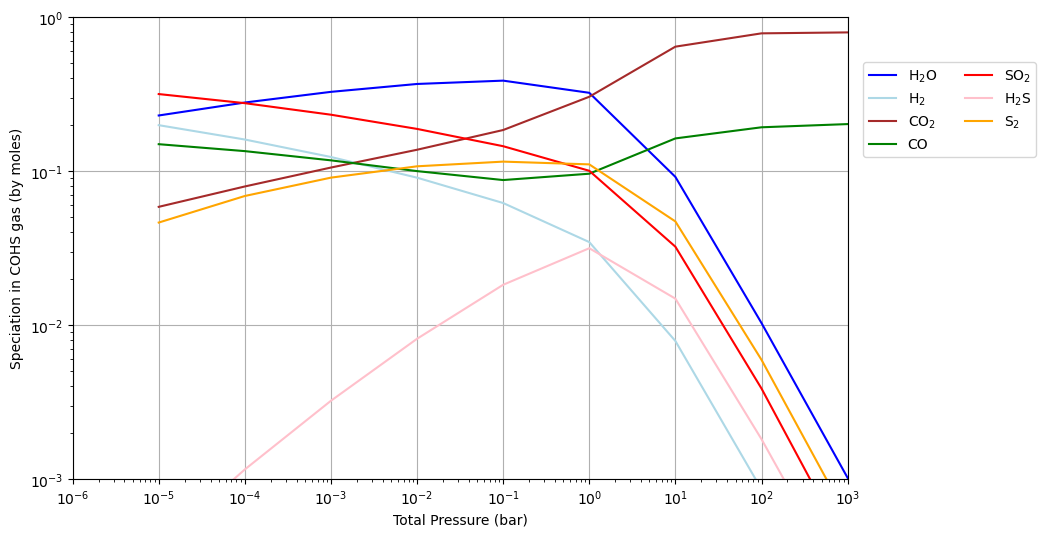

In [5]:
### Outgassing calcuation

T = 1300 + 273.15  # C + 273.15 = K
mH2O_sat = 700 * 1e-6 # magma H2O content at saturation in ppm wt -- actually just H content
mCO2_sat = 500 * 1e-6 # magma CO2 content at saturation in ppm wt -- actually just C content
mS_sat = 1200 * 1e-6 # magma S content at saturation in ppm wt -- just S content
FMQ_sat = -1.4 # fO2 at saturation relative to FMQ buffer
alphaG_sat = 0.05 * 1e-2 # Assume amount of gas in melt at saturation by mol (0.3-0.7 wt% from IM 2012; 0.01 wt% for GS 2009)
FeO_star_wt = 6 * 1e-2 # Total FeO in melt

outgassing_precalc = calc_outgassing(T, mH2O_sat, mCO2_sat, mS_sat, FMQ_sat, alphaG_sat, FeO_star_wt, verbose=False)
plot_speciation(outgassing_precalc)

In [6]:
import os
import multiprocessing as mp
from concurrent.futures import ProcessPoolExecutor

NSAMPLES = 100000

# Set up an output file to store results
filename = "outgassing_grid_{:d}samples_MARCH03.npz".format(NSAMPLES)

# Define column headers
columns = ["FMQ_sat", "mH2O_sat", "mCO2_sat", "mS_sat", "FeO_star_wt", "T", "alphaG_sat", "P_tot",
           "x_H2O_atm_input", "x_H2_atm_input", "x_CO2_atm_input", "x_CO_atm_input",
           "x_CH4_atm_input", "x_S2_atm_input", "x_SO2_atm_input", "x_H2S_atm_input", "mu_gas_atm_input"]

T = 1300 + 273.15  # C + 273.15 = K
alphaG_sat = 0.05 * 1e-2 # Assume amount of gas in melt at saturation by mol (0.3-0.7 wt% from IM 2012; 0.01 wt% for GS 2009)

FMQ_sat_range = (-4, 0)
m_H2O_sat_range = np.array([10, 2000], dtype=float) * 1e-6 # ppm wt -- actually just H content
m_CO2_sat_range = np.array([10, 2000], dtype=float) * 1e-6 # ppm wt -- actually just C content
m_S_sat_range = np.array([10, 2000], dtype=float) * 1e-6 # ppm wt -- actually just S content
FeO_star_wt_range = np.array([1, 20], dtype=float) * 1e-2  # wt% * 1e-2
P_targets = np.array([1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 1, 10, 100], dtype=float) # bar

# Avoid CPU oversubscription in each worker process
os.environ.setdefault('OMP_NUM_THREADS', '1')
os.environ.setdefault('MKL_NUM_THREADS', '1')

def _nan_row(FMQ_sat, mH2O_sat, mCO2_sat, mS_sat, FeO_star_wt, P_fail):
    return [FMQ_sat, mH2O_sat, mCO2_sat, mS_sat, FeO_star_wt, T, alphaG_sat, P_fail,
            np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan]

def _run_single_sample(sample_vals):
    mH2O_sat, mCO2_sat, mS_sat, FMQ_sat, FeO_star_wt = [float(v) for v in sample_vals]

    outgassing_result = calc_outgassing(T, mH2O_sat, mCO2_sat, mS_sat, FMQ_sat, alphaG_sat, FeO_star_wt, verbose=False)
    P_grid = np.asarray(outgassing_result.get('P', []), dtype=float)

    sample_rows = []
    finite_p_idx = np.where(np.isfinite(P_grid))[0]

    for P_target in P_targets:
        if finite_p_idx.size == 0:
            sample_rows.append(_nan_row(FMQ_sat, mH2O_sat, mCO2_sat, mS_sat, FeO_star_wt, float(P_target)))
            continue

        idx_local = int(np.argmin(np.abs(P_grid[finite_p_idx] - P_target)))
        idx = int(finite_p_idx[idx_local])
        P_at_target = float(P_grid[idx])

        if (not np.isfinite(P_at_target)) or (abs(P_at_target - P_target) > 0.1 * P_target):
            sample_rows.append(_nan_row(FMQ_sat, mH2O_sat, mCO2_sat, mS_sat, FeO_star_wt, float(P_target)))
            continue

        try:
            species_partial = np.array([
                outgassing_result['H2O'][idx], outgassing_result['H2'][idx], outgassing_result['CO2'][idx], outgassing_result['CO'][idx],
                outgassing_result['CH4'][idx], outgassing_result['S2'][idx], outgassing_result['SO2'][idx], outgassing_result['H2S'][idx],
            ], dtype=float)
        except Exception:
            sample_rows.append(_nan_row(FMQ_sat, mH2O_sat, mCO2_sat, mS_sat, FeO_star_wt, float(P_target)))
            continue

        if (P_at_target <= 0) or (not np.isfinite(P_at_target)) or (not np.all(np.isfinite(species_partial))):
            sample_rows.append(_nan_row(FMQ_sat, mH2O_sat, mCO2_sat, mS_sat, FeO_star_wt, float(P_target)))
            continue

        x_H2O_gas = species_partial[0] / P_at_target
        x_H2_gas = species_partial[1] / P_at_target
        x_CO2_gas = species_partial[2] / P_at_target
        x_CO_gas = species_partial[3] / P_at_target
        x_CH4_gas = species_partial[4] / P_at_target
        x_S2_gas = species_partial[5] / P_at_target
        x_SO2_gas = species_partial[6] / P_at_target
        x_H2S_gas = species_partial[7] / P_at_target

        mu_gas = (x_H2O_gas * mu_dict['H2O'] +
                  x_H2_gas * mu_dict['H2'] +
                  x_CO2_gas * mu_dict['CO2'] +
                  x_CO_gas * mu_dict['CO'] +
                  x_CH4_gas * mu_dict['CH4'] +
                  x_S2_gas * mu_dict['S2'] +
                  x_SO2_gas * mu_dict['SO2'] +
                  x_H2S_gas * mu_dict['H2S'])

        if not np.isfinite(mu_gas):
            sample_rows.append(_nan_row(FMQ_sat, mH2O_sat, mCO2_sat, mS_sat, FeO_star_wt, float(P_target)))
            continue

        sample_rows.append([FMQ_sat, mH2O_sat, mCO2_sat, mS_sat, FeO_star_wt, T, alphaG_sat, float(P_target),
                            x_H2O_gas, x_H2_gas, x_CO2_gas, x_CO_gas, x_CH4_gas, x_S2_gas, x_SO2_gas, x_H2S_gas, mu_gas])

    return np.asarray(sample_rows, dtype=float)

rng = np.random.default_rng()
samples = np.column_stack([
    rng.uniform(m_H2O_sat_range[0], m_H2O_sat_range[1], NSAMPLES),
    rng.uniform(m_CO2_sat_range[0], m_CO2_sat_range[1], NSAMPLES),
    rng.uniform(m_S_sat_range[0], m_S_sat_range[1], NSAMPLES),
    rng.uniform(FMQ_sat_range[0], FMQ_sat_range[1], NSAMPLES),
    rng.uniform(FeO_star_wt_range[0], FeO_star_wt_range[1], NSAMPLES),
]).astype(float)

max_workers = min(NSAMPLES, os.cpu_count() or 1)
chunksize = max(1, NSAMPLES // max(1, max_workers * 4))
print(f'Running {NSAMPLES} samples with up to {max_workers} workers (chunksize={chunksize})')

rows_chunks = None
try:
    ctx = mp.get_context('fork')
except ValueError:
    ctx = None

if (ctx is not None) and (max_workers > 1):
    try:
        with ProcessPoolExecutor(max_workers=max_workers, mp_context=ctx) as ex:
            rows_chunks = list(ex.map(_run_single_sample, samples, chunksize=chunksize))
    except Exception as exc:
        print(f'Warning: Parallel execution failed ({exc}). Falling back to serial execution.')

if rows_chunks is None:
    rows_chunks = [_run_single_sample(sample) for sample in samples]

if rows_chunks:
    data = np.vstack(rows_chunks).astype(float, copy=False)
else:
    data = np.empty((0, len(columns)), dtype=float)

np.savez(filename, columns=np.asarray(columns), data=data)
print(f'Saved grid with shape {data.shape} to {filename}')


Running 100000 samples with up to 10 workers (chunksize=2500)
Saved grid with shape (800000, 17) to outgassing_grid_100000samples_MARCH03.npz


In [36]:
d = np.load(filename, allow_pickle=False)
print(d.files)  # e.g. ['columns', 'data']

print(d["data"].shape, d["data"].dtype)
df = pd.DataFrame(d["data"], columns=d["columns"])

# pd.set_option("display.max_rows", None)
# pd.set_option("display.max_columns", None)
# pd.set_option("display.width", None)
# pd.set_option("display.max_colwidth", None)
df.head()


['columns', 'data']
(800000, 17) float64


,FMQ_sat,mH2O_sat,mCO2_sat,mS_sat,FeO_star_wt,T,alphaG_sat,P_tot,x_H2O_atm_input,x_H2_atm_input,x_CO2_atm_input,x_CO_atm_input,x_CH4_atm_input,x_S2_atm_input,x_SO2_atm_input,x_H2S_atm_input,mu_gas_atm_input
0,-2.496481,0.001614,0.001891,0.001959,0.170328,1573.15,0.0005,0.00001,0.266313,0.186615,0.084619,0.174901,8.584095e-19,0.014799,0.272555,0.000197,32.214420
1,-2.496481,0.001614,0.001891,0.001959,0.170328,1573.15,0.0005,0.00010,0.309423,0.156679,0.107378,0.160379,4.009411e-17,0.030078,0.235317,0.000746,32.138613
2,-2.496481,0.001614,0.001891,0.001959,0.170328,1573.15,0.0005,0.00100,0.360838,0.124746,0.139263,0.142012,1.536559e-15,0.042086,0.188835,0.002220,31.731784
3,-2.496481,0.001614,0.001891,0.001959,0.170328,1573.15,0.0005,0.01000,0.415563,0.095881,0.180969,0.123161,5.253931e-14,0.043173,0.135787,0.005466,30.748724
4,-2.496481,0.001614,0.001891,0.001959,0.170328,1573.15,0.0005,0.10000,0.462737,0.072699,0.237281,0.109959,1.836308e-12,0.029676,0.076781,0.010866,29.198348


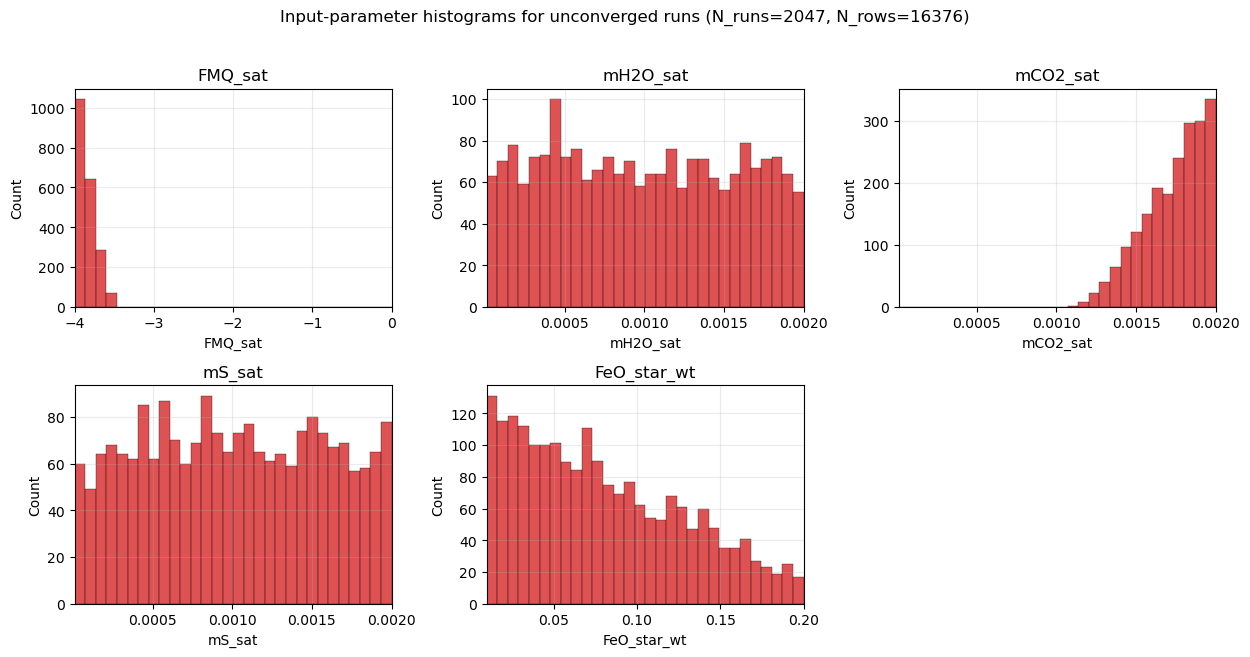

In [37]:
# Histograms of sampled input parameters for runs that did not converge
if 'df' not in globals():
    d = np.load(filename, allow_pickle=False)
    df = pd.DataFrame(d['data'], columns=d['columns'])
df_plot = df.copy()
df_plot.columns = [str(c) for c in df_plot.columns]
input_cols = ['FMQ_sat', 'mH2O_sat', 'mCO2_sat', 'mS_sat', 'FeO_star_wt']
input_cols = [c for c in input_cols if c in df_plot.columns]
if not input_cols:
    raise KeyError(f'No recognized sampled-input columns found. Available columns: {list(df_plot.columns)}')
# Use sampled ranges for x-axis limits. Pull from notebook globals when available,
# otherwise fall back to the defaults used in this notebook.
sampled_bounds = {
    'FMQ_sat': tuple(np.asarray(globals().get('FMQ_sat_range', (-4.0, 0.0)), dtype=float)),
    'mH2O_sat': tuple(np.asarray(globals().get('m_H2O_sat_range', np.array([10.0, 1000.0]) * 1e-6), dtype=float)),
    'mCO2_sat': tuple(np.asarray(globals().get('m_CO2_sat_range', np.array([10.0, 1000.0]) * 1e-6), dtype=float)),
    'mS_sat': tuple(np.asarray(globals().get('m_S_sat_range', np.array([10.0, 1000.0]) * 1e-6), dtype=float)),
    'FeO_star_wt': tuple(np.asarray(globals().get('FeO_star_wt_range', np.array([5.0, 20.0]) * 1e-2), dtype=float)),
}
# Normalize bounds to (low, high) floats
for k, b in list(sampled_bounds.items()):
    bb = np.asarray(b, dtype=float).ravel()
    if bb.size < 2:
        raise ValueError(f'Range for {k} must have at least 2 entries, got: {b}')
    lo, hi = float(bb[0]), float(bb[1])
    if hi < lo:
        lo, hi = hi, lo
    sampled_bounds[k] = (lo, hi)
pressure_targets = np.asarray(globals().get('P_targets', np.array([1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 1.0, 10.0, 100.0])), dtype=float).ravel()
if pressure_targets.size == 0:
    pressure_targets = np.array([1e-5, 100.0], dtype=float)
pressure_bounds = (float(np.nanmin(pressure_targets)), float(np.nanmax(pressure_targets)))
model_output_candidates = [
    'mu_gas', 'mu_gas_atm_input',
    'x_H2O_gas', 'x_H2_gas', 'x_CO2_gas', 'x_CO_gas', 'x_CH4_gas', 'x_S2_gas', 'x_SO2_gas', 'x_H2S_gas',
    'x_H2O_atm_input', 'x_H2_atm_input', 'x_CO2_atm_input', 'x_CO_atm_input',
    'x_CH4_atm_input', 'x_S2_atm_input', 'x_SO2_atm_input', 'x_H2S_atm_input',
]
model_output_cols = [c for c in model_output_candidates if c in df_plot.columns]
if not model_output_cols:
    raise KeyError(f'No recognized model-output columns found. Available columns: {list(df_plot.columns)}')
# A row is treated as unconverged if all model-output fields are NaN.
row_unconverged = df_plot[model_output_cols].isna().all(axis=1)
failed_rows = df_plot.loc[row_unconverged].copy()
failed_runs = failed_rows[input_cols].drop_duplicates()
if failed_rows.empty:
    print('No unconverged model runs found in this file.')
else:
    panel_data = []
    # Input-parameter panels (deduplicated by run).
    for col in input_cols:
        vals = pd.to_numeric(failed_runs[col], errors='coerce').to_numpy(dtype=float)
        vals = vals[np.isfinite(vals)]
        lo, hi = sampled_bounds[col]
        panel_data.append((col, vals, lo, hi))
    n = len(panel_data)
    ncols = min(3, n)
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(4.2 * ncols, 3.2 * nrows))
    axes = np.atleast_1d(axes).ravel()
    for i, (label, vals, lo, hi) in enumerate(panel_data):
        ax = axes[i]
        bins = np.linspace(lo, hi, 31)
        if vals.size == 0:
            ax.text(0.5, 0.5, 'No finite values', ha='center', va='center', transform=ax.transAxes)
            ax.set_title(label)
            ax.set_yticks([])
        else:
            ax.hist(vals, bins=bins, color='tab:red', alpha=0.8, edgecolor='black', linewidth=0.3)
            ax.set_title(label)
            ax.set_xlabel(label)
            ax.set_ylabel('Count')
            ax.grid(alpha=0.25)
        # Force x-axis limits to sampled parameter bounds
        ax.set_xlim(lo, hi)
    for j in range(n, len(axes)):
        axes[j].axis('off')
    fig.suptitle(f'Input-parameter histograms for unconverged runs (N_runs={len(failed_runs)}, N_rows={len(failed_rows)})', y=1.02)
    plt.tight_layout()
    plt.show()


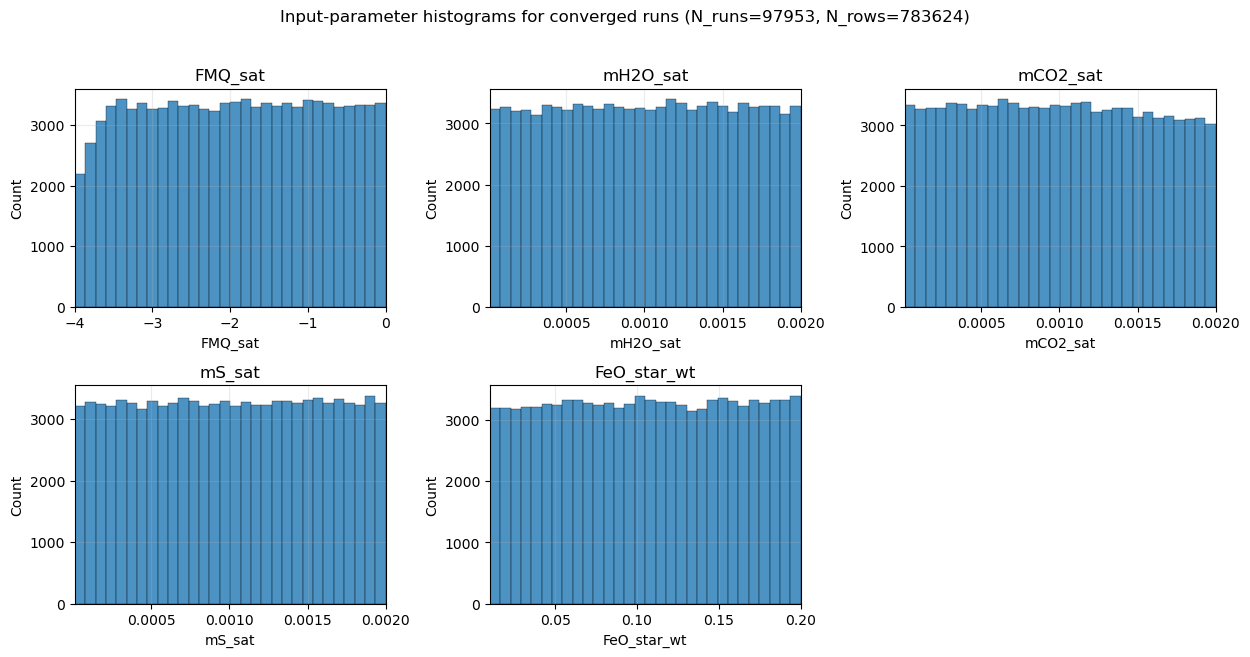

In [38]:
# Histograms of sampled input parameters for runs that converged
if 'df' not in globals():
    d = np.load(filename, allow_pickle=False)
    df = pd.DataFrame(d['data'], columns=d['columns'])
df_plot = df.copy()
df_plot.columns = [str(c) for c in df_plot.columns]
input_cols = ['FMQ_sat', 'mH2O_sat', 'mCO2_sat', 'mS_sat', 'FeO_star_wt']
input_cols = [c for c in input_cols if c in df_plot.columns]
if not input_cols:
    raise KeyError(f'No recognized sampled-input columns found. Available columns: {list(df_plot.columns)}')
# Use sampled ranges for x-axis limits. Pull from notebook globals when available,
# otherwise fall back to the defaults used in this notebook.
sampled_bounds = {
    'FMQ_sat': tuple(np.asarray(globals().get('FMQ_sat_range', (-4.0, 0.0)), dtype=float)),
    'mH2O_sat': tuple(np.asarray(globals().get('m_H2O_sat_range', np.array([10.0, 1000.0]) * 1e-6), dtype=float)),
    'mCO2_sat': tuple(np.asarray(globals().get('m_CO2_sat_range', np.array([10.0, 1000.0]) * 1e-6), dtype=float)),
    'mS_sat': tuple(np.asarray(globals().get('m_S_sat_range', np.array([10.0, 1000.0]) * 1e-6), dtype=float)),
    'FeO_star_wt': tuple(np.asarray(globals().get('FeO_star_wt_range', np.array([5.0, 20.0]) * 1e-2), dtype=float)),
}
# Normalize bounds to (low, high) floats
for k, b in list(sampled_bounds.items()):
    bb = np.asarray(b, dtype=float).ravel()
    if bb.size < 2:
        raise ValueError(f'Range for {k} must have at least 2 entries, got: {b}')
    lo, hi = float(bb[0]), float(bb[1])
    if hi < lo:
        lo, hi = hi, lo
    sampled_bounds[k] = (lo, hi)
pressure_targets = np.asarray(globals().get('P_targets', np.array([1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 1.0, 10.0, 100.0])), dtype=float).ravel()
if pressure_targets.size == 0:
    pressure_targets = np.array([1e-5, 100.0], dtype=float)
pressure_bounds = (float(np.nanmin(pressure_targets)), float(np.nanmax(pressure_targets)))
model_output_candidates = [
    'mu_gas', 'mu_gas_atm_input',
    'x_H2O_gas', 'x_H2_gas', 'x_CO2_gas', 'x_CO_gas', 'x_CH4_gas', 'x_S2_gas', 'x_SO2_gas', 'x_H2S_gas',
    'x_H2O_atm_input', 'x_H2_atm_input', 'x_CO2_atm_input', 'x_CO_atm_input',
    'x_CH4_atm_input', 'x_S2_atm_input', 'x_SO2_atm_input', 'x_H2S_atm_input',
]
model_output_cols = [c for c in model_output_candidates if c in df_plot.columns]
if not model_output_cols:
    raise KeyError(f'No recognized model-output columns found. Available columns: {list(df_plot.columns)}')
# A row is treated as unconverged if all model-output fields are NaN.
row_unconverged = df_plot[model_output_cols].isna().all(axis=1)
converged_rows = df_plot.loc[~row_unconverged].copy()
converged_runs = converged_rows[input_cols].drop_duplicates()
if converged_rows.empty:
    print('No converged model runs found in this file.')
else:
    panel_data = []
    # Input-parameter panels (deduplicated by run).
    for col in input_cols:
        vals = pd.to_numeric(converged_runs[col], errors='coerce').to_numpy(dtype=float)
        vals = vals[np.isfinite(vals)]
        lo, hi = sampled_bounds[col]
        panel_data.append((col, vals, lo, hi))
    n = len(panel_data)
    ncols = min(3, n)
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(4.2 * ncols, 3.2 * nrows))
    axes = np.atleast_1d(axes).ravel()
    for i, (label, vals, lo, hi) in enumerate(panel_data):
        ax = axes[i]
        bins = np.linspace(lo, hi, 31)
        if vals.size == 0:
            ax.text(0.5, 0.5, 'No finite values', ha='center', va='center', transform=ax.transAxes)
            ax.set_title(label)
            ax.set_yticks([])
        else:
            ax.hist(vals, bins=bins, color='tab:blue', alpha=0.8, edgecolor='black', linewidth=0.3)
            ax.set_title(label)
            ax.set_xlabel(label)
            ax.set_ylabel('Count')
            ax.grid(alpha=0.25)
        # Force x-axis limits to sampled parameter bounds
        ax.set_xlim(lo, hi)
    for j in range(n, len(axes)):
        axes[j].axis('off')
    fig.suptitle(f'Input-parameter histograms for converged runs (N_runs={len(converged_runs)}, N_rows={len(converged_rows)})', y=1.02)
    plt.tight_layout()
    plt.show()


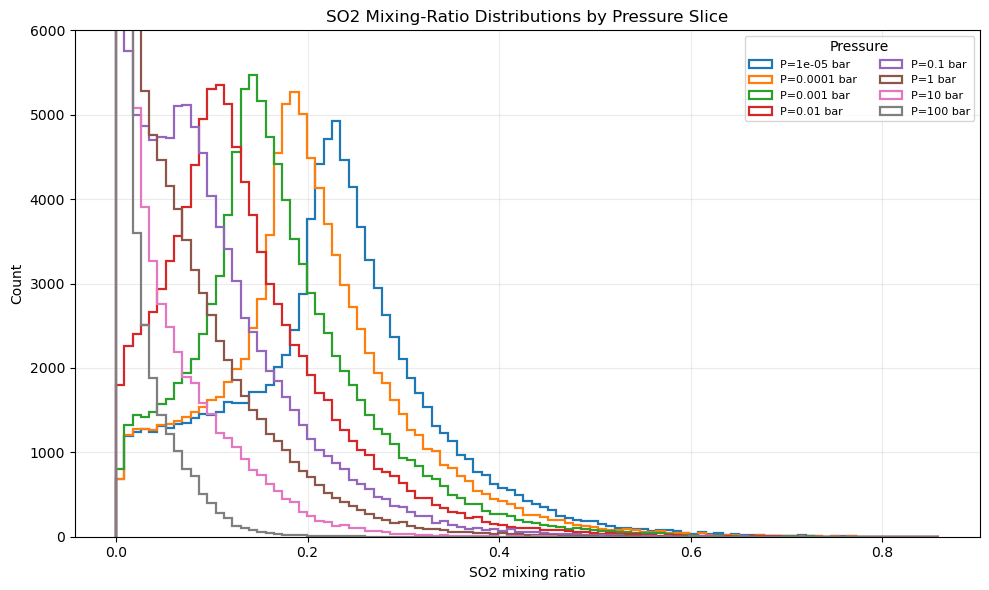

In [41]:
# SO2 mixing-ratio distribution for each pressure slice (single panel)
if 'df' not in globals():
    d = np.load(filename, allow_pickle=False)
    df = pd.DataFrame(d['data'], columns=d['columns'])
df_plot = df.copy()
df_plot.columns = [str(c) for c in df_plot.columns]
pressure_col = None
for candidate in ['P_tot', 'P']:
    if candidate in df_plot.columns:
        pressure_col = candidate
        break
if pressure_col is None:
    raise KeyError(f"Could not find pressure column. Available columns: {list(df_plot.columns)}")
so2_col = None
for candidate in ['x_SO2_atm_input', 'x_SO2_gas', 'x_SO2']:
    if candidate in df_plot.columns:
        so2_col = candidate
        break
if so2_col is None:
    raise KeyError(f"Could not find SO2 mixing-ratio column. Available columns: {list(df_plot.columns)}")
p_vals = pd.to_numeric(df_plot[pressure_col], errors='coerce').to_numpy(dtype=float)
so2_vals = pd.to_numeric(df_plot[so2_col], errors='coerce').to_numpy(dtype=float)
finite_mask = np.isfinite(p_vals) & np.isfinite(so2_vals)
if not np.any(finite_mask):
    raise ValueError('No finite SO2 mixing-ratio values found to plot.')
p_unique = np.unique(p_vals[finite_mask])
p_unique = np.sort(p_unique)
all_so2 = so2_vals[finite_mask]
if np.allclose(all_so2.min(), all_so2.max()):
    bins = 20
else:
    bins = np.linspace(all_so2.min(), all_so2.max(), 100)
fig, ax = plt.subplots(figsize=(10, 6))
n_plotted = 0
for p in p_unique:
    m = finite_mask & np.isclose(p_vals, p, rtol=1e-6, atol=0.0)
    vals = so2_vals[m]
    vals = vals[np.isfinite(vals)]
    if vals.size == 0:
        continue
    ax.hist(vals, bins=bins, density=False, histtype='step', linewidth=1.6, label=f'P={p:g} bar')
    n_plotted += 1
if n_plotted == 0:
    raise ValueError('No pressure slices had finite SO2 values after filtering.')
ax.set_xlabel('SO2 mixing ratio')
ax.set_ylabel('Count')
ax.set_title('SO2 Mixing-Ratio Distributions by Pressure Slice')
ax.set_ylim(0, 6000)
ax.legend(title='Pressure', fontsize=8, ncol=2)
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()


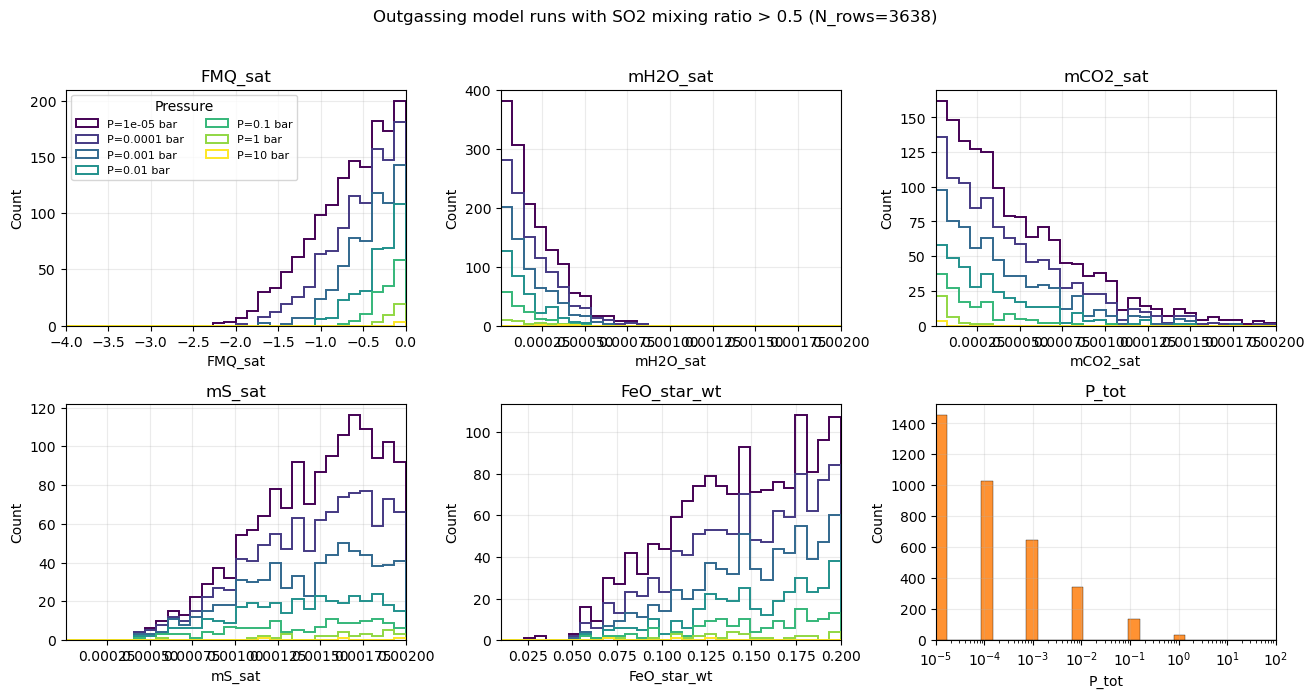

In [42]:
# Histograms for runs with SO2 mixing ratio > 0.5, split by pressure slice
so2_threshold = 0.5

if 'df' not in globals():
    d = np.load(filename, allow_pickle=False)
    df = pd.DataFrame(d['data'], columns=d['columns'])

df_plot = df.copy()
df_plot.columns = [str(c) for c in df_plot.columns]

so2_col = next((c for c in ['x_SO2_atm_input', 'x_SO2_gas', 'x_SO2'] if c in df_plot.columns), None)
pressure_col = next((c for c in ['P_tot', 'P'] if c in df_plot.columns), None)
if so2_col is None:
    raise KeyError(f"Could not find SO2 mixing-ratio column. Available columns: {list(df_plot.columns)}")
if pressure_col is None:
    raise KeyError(f"Could not find pressure column. Available columns: {list(df_plot.columns)}")

input_cols = [c for c in ['FMQ_sat', 'mH2O_sat', 'mCO2_sat', 'mS_sat', 'FeO_star_wt'] if c in df_plot.columns]
if not input_cols:
    raise KeyError(f"Could not find sampled input columns. Available columns: {list(df_plot.columns)}")

def _norm_bounds(bounds):
    b = np.asarray(bounds, dtype=float).ravel()
    lo, hi = float(b[0]), float(b[1])
    return (lo, hi) if lo <= hi else (hi, lo)

sampled_bounds = {
    'FMQ_sat': _norm_bounds(globals().get('FMQ_sat_range', (-4.0, 0.0))),
    'mH2O_sat': _norm_bounds(globals().get('m_H2O_sat_range', np.array([10.0, 1000.0]) * 1e-6)),
    'mCO2_sat': _norm_bounds(globals().get('m_CO2_sat_range', np.array([10.0, 1000.0]) * 1e-6)),
    'mS_sat': _norm_bounds(globals().get('m_S_sat_range', np.array([10.0, 1000.0]) * 1e-6)),
    'FeO_star_wt': _norm_bounds(globals().get('FeO_star_wt_range', np.array([1.0, 20.0]) * 1e-2)),
}

p_targets = np.asarray(globals().get('P_targets', np.array([1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 1.0, 10.0, 100.0])), dtype=float)
p_targets = p_targets[np.isfinite(p_targets)]
if p_targets.size == 0:
    p_targets = np.array([1e-5, 100.0], dtype=float)
pressure_bounds = (float(np.min(p_targets)), float(np.max(p_targets)))

so2_vals = pd.to_numeric(df_plot[so2_col], errors='coerce').to_numpy(dtype=float)
selected = df_plot.loc[np.isfinite(so2_vals) & (so2_vals > so2_threshold)].copy()

if selected.empty:
    print(f'No rows found with {so2_col} > {so2_threshold}.')
else:
    p_vals = pd.to_numeric(selected[pressure_col], errors='coerce').to_numpy(dtype=float)
    finite_p = np.isfinite(p_vals)
    selected = selected.loc[finite_p].copy()
    p_vals = p_vals[finite_p]

    if p_vals.size == 0:
        raise ValueError('No finite pressure values in selected rows.')

    pressure_slices = np.sort(np.unique(p_vals))
    colors = plt.cm.viridis(np.linspace(0, 1, len(pressure_slices)))

    panel_labels = input_cols + [pressure_col]
    n = len(panel_labels)
    ncols = 3
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(4.4 * ncols, 3.4 * nrows))
    axes = np.atleast_1d(axes).ravel()

    for i, label in enumerate(panel_labels):
        ax = axes[i]

        if label == pressure_col:
            lo, hi = pressure_bounds
            bins = np.logspace(np.log10(lo), np.log10(hi), 31) if (lo > 0 and hi > 0 and lo < hi) else np.linspace(lo, hi, 31)
            vals = p_vals[np.isfinite(p_vals)]
            if vals.size == 0:
                ax.text(0.5, 0.5, 'No finite values', ha='center', va='center', transform=ax.transAxes)
                ax.set_yticks([])
            else:
                ax.hist(vals, bins=bins, color='tab:orange', alpha=0.85, edgecolor='black', linewidth=0.3)
            ax.set_title(label)
            ax.set_xlabel(label)
            ax.set_ylabel('Count')
            ax.grid(alpha=0.25)
            ax.set_xlim(lo, hi)
            if lo > 0 and hi > 0 and lo < hi:
                ax.set_xscale('log')
            continue

        lo, hi = sampled_bounds[label]
        bins = np.linspace(lo, hi, 31)
        plotted_any = False

        for p_slice, color in zip(pressure_slices, colors):
            mask = np.isclose(p_vals, p_slice, rtol=1e-6, atol=0.0)
            vals = pd.to_numeric(selected.loc[mask, label], errors='coerce').to_numpy(dtype=float)
            vals = vals[np.isfinite(vals)]
            if vals.size == 0:
                continue
            ax.hist(vals, bins=bins, histtype='step', linewidth=1.4, color=color, label=f'P={p_slice:g} bar')
            plotted_any = True

        if not plotted_any:
            ax.text(0.5, 0.5, 'No finite values', ha='center', va='center', transform=ax.transAxes)
            ax.set_yticks([])

        ax.set_title(label)
        ax.set_xlabel(label)
        ax.set_ylabel('Count')
        ax.grid(alpha=0.25)
        ax.set_xlim(lo, hi)

    if len(pressure_slices) > 0:
        axes[0].legend(title='Pressure', fontsize=8, ncol=2)

    for j in range(n, len(axes)):
        axes[j].axis('off')

    fig.suptitle(
        f'Outgassing model runs with SO2 mixing ratio > {so2_threshold} '
        f'(N_rows={len(selected)})', # change this to N_runs if you prefer counting unique input parameter sets instead of total rows
        y=1.02
    )
    plt.tight_layout()
    plt.show()



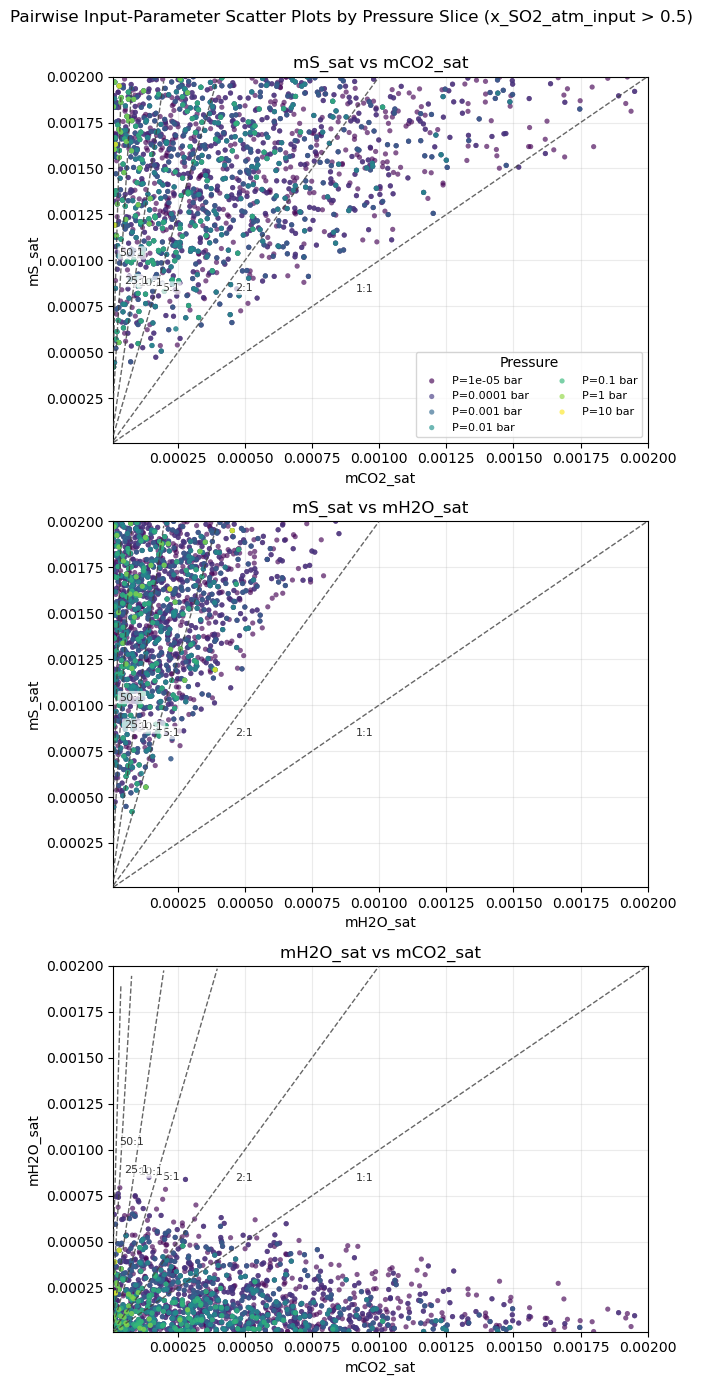

In [43]:
# Pairwise scatter plots for sampled volatile inputs, colored by pressure slice
# Only includes runs with SO2 mixing ratio > threshold
so2_threshold = 0.5

if 'df' not in globals():
    d = np.load(filename, allow_pickle=False)
    df = pd.DataFrame(d['data'], columns=d['columns'])

df_plot = df.copy()
df_plot.columns = [str(c) for c in df_plot.columns]

pressure_col = next((c for c in ['P_tot', 'P'] if c in df_plot.columns), None)
so2_col = next((c for c in ['x_SO2_atm_input', 'x_SO2_gas', 'x_SO2'] if c in df_plot.columns), None)
if pressure_col is None:
    raise KeyError(f"Could not find pressure column. Available columns: {list(df_plot.columns)}")
if so2_col is None:
    raise KeyError(f"Could not find SO2 mixing-ratio column. Available columns: {list(df_plot.columns)}")

pair_cols = ['mS_sat', 'mCO2_sat', 'mH2O_sat']
missing = [c for c in pair_cols if c not in df_plot.columns]
if missing:
    raise KeyError(f"Missing required columns for scatter plots: {missing}")

def _norm_bounds(bounds):
    b = np.asarray(bounds, dtype=float).ravel()
    lo, hi = float(b[0]), float(b[1])
    return (lo, hi) if lo <= hi else (hi, lo)

sampled_bounds = {
    'mS_sat': _norm_bounds(globals().get('m_S_sat_range', np.array([10.0, 1000.0]) * 1e-6)),
    'mCO2_sat': _norm_bounds(globals().get('m_CO2_sat_range', np.array([10.0, 1000.0]) * 1e-6)),
    'mH2O_sat': _norm_bounds(globals().get('m_H2O_sat_range', np.array([10.0, 1000.0]) * 1e-6)),
}

plot_cols = pair_cols + [pressure_col, so2_col]
plot_df = df_plot[plot_cols].copy()
for c in plot_cols:
    plot_df[c] = pd.to_numeric(plot_df[c], errors='coerce')

mask = np.isfinite(plot_df[plot_cols]).all(axis=1) & (plot_df[so2_col] > so2_threshold)
plot_df = plot_df.loc[mask].copy()

if plot_df.empty:
    raise ValueError(f'No finite rows available with {so2_col} > {so2_threshold}.')

p_vals = plot_df[pressure_col].to_numpy(dtype=float)
pressure_slices = np.sort(np.unique(p_vals))
colors = plt.cm.viridis(np.linspace(0, 1, len(pressure_slices)))

pairs = [
    ('mCO2_sat', 'mS_sat'),
    ('mH2O_sat', 'mS_sat'),
    ('mCO2_sat', 'mH2O_sat'),
]
ratio_levels = [1, 2, 5, 10, 25, 50]

fig, axes = plt.subplots(3, 1, figsize=(6.8, 13.8))
axes = np.atleast_1d(axes)

for i, (ax, (xcol, ycol)) in enumerate(zip(axes, pairs)):
    xlo, xhi = sampled_bounds[xcol]
    ylo, yhi = sampled_bounds[ycol]

    # Scatter points by pressure slice
    for p, color in zip(pressure_slices, colors):
        m = np.isclose(p_vals, p, rtol=1e-6, atol=0.0)
        if not np.any(m):
            continue
        label = f'P={p:g} bar' if i == 0 else None
        ax.scatter(
            plot_df.loc[m, xcol],
            plot_df.loc[m, ycol],
            s=14,
            alpha=0.65,
            color=color,
            edgecolors='none',
            label=label,
            rasterized=True,
            zorder=2,
        )

    # Ratio guides y = r*x (drawn above points)
    x_line = np.linspace(xlo, xhi, 500)
    for r in ratio_levels:
        y_line = r * x_line
        vis = (y_line >= ylo) & (y_line <= yhi)
        if not np.any(vis):
            continue
        ax.plot(
            x_line[vis],
            y_line[vis],
            linestyle='--',
            linewidth=1.0,
            color='0.25',
            alpha=0.8,
            zorder=4,
        )
        vis_idx = np.where(vis)[0]
        i_label = vis_idx[int(0.45 * (len(vis_idx) - 1))]
        ax.annotate(
            f'{r}:1',
            (x_line[i_label], y_line[i_label]),
            xytext=(2, -4),
            textcoords='offset points',
            fontsize=8,
            color='0.2',
            ha='left',
            va='top',
            clip_on=True,
            zorder=5,
            bbox=dict(boxstyle='round,pad=0.15', facecolor='white', edgecolor='none', alpha=0.7),
        )

    ax.set_xlim(xlo, xhi)
    ax.set_ylim(ylo, yhi)
    ax.set_xlabel(xcol)
    ax.set_ylabel(ycol)
    ax.set_title(f'{ycol} vs {xcol}')
    ax.grid(alpha=0.25)

axes[0].legend(title='Pressure', fontsize=8, ncol=2)
fig.suptitle(f'Pairwise Input-Parameter Scatter Plots by Pressure Slice ({so2_col} > {so2_threshold})', y=1.0)
plt.tight_layout()
plt.show()




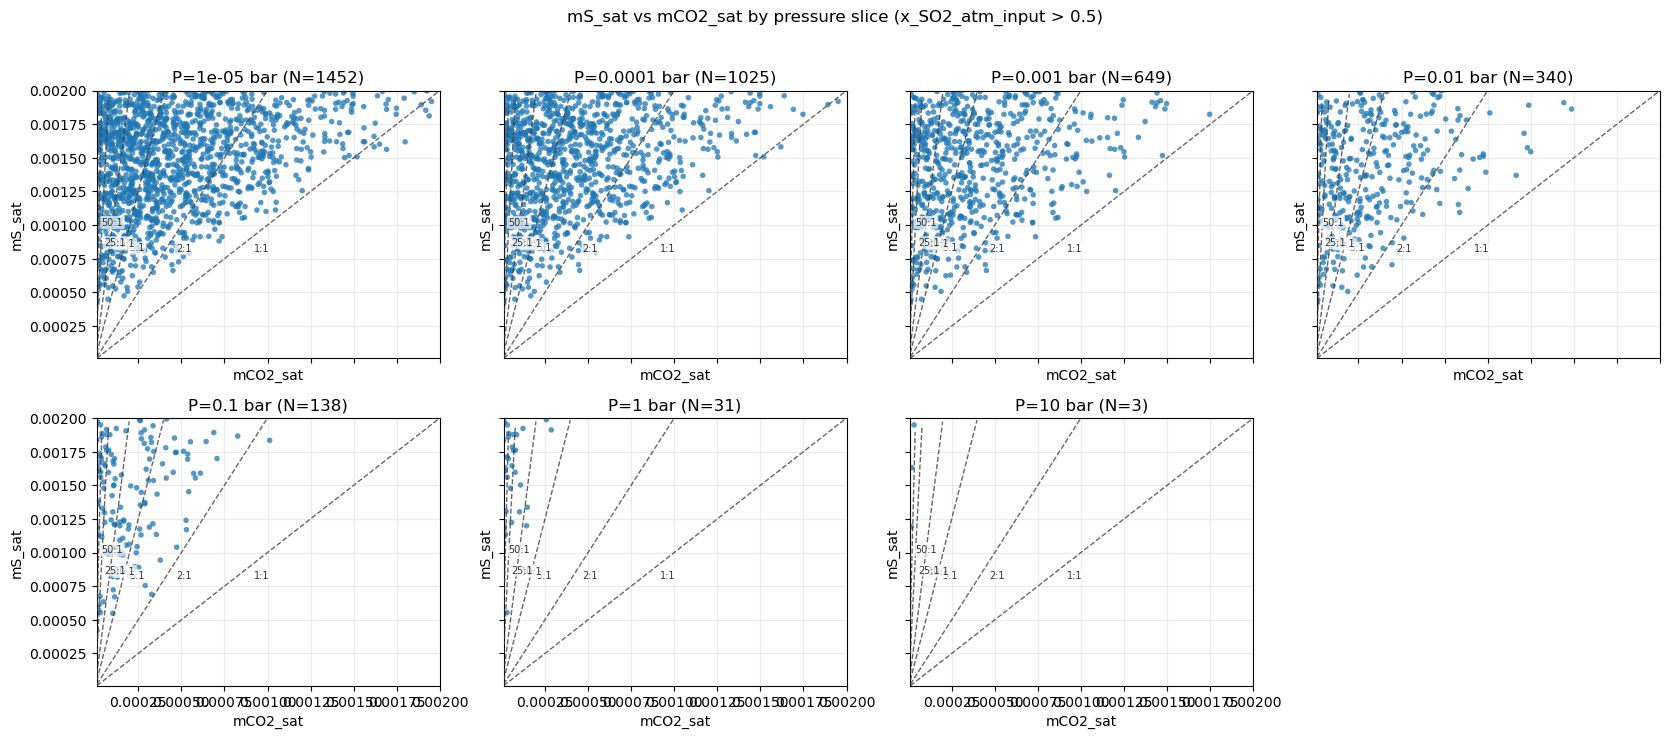

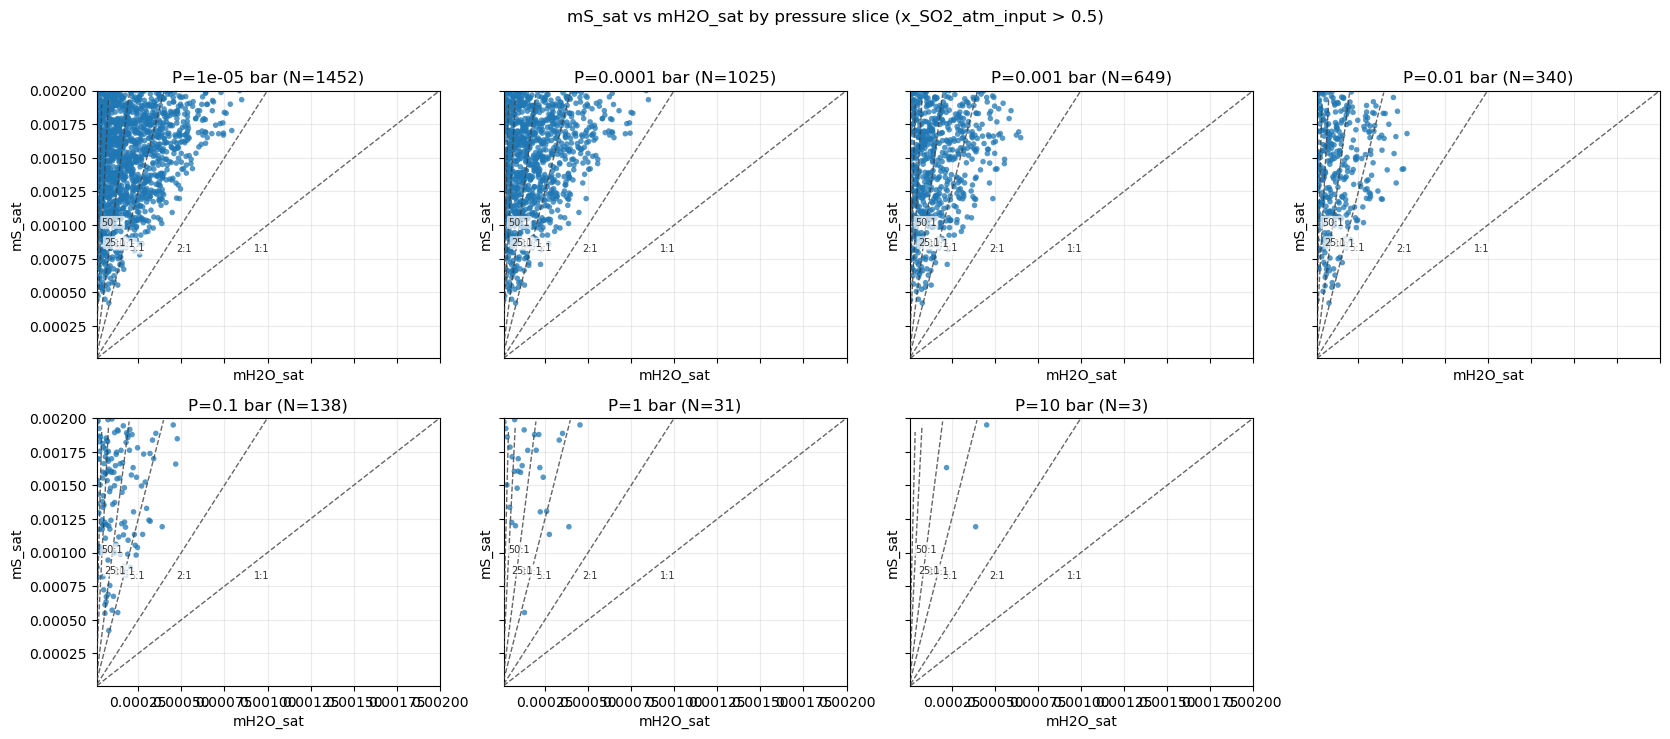

In [44]:
# Sulfur-focused scatter plots faceted by pressure slice (SO2 > threshold)
so2_threshold = 0.5

if 'df' not in globals():
    d = np.load(filename, allow_pickle=False)
    df = pd.DataFrame(d['data'], columns=d['columns'])

df_plot = df.copy()
df_plot.columns = [str(c) for c in df_plot.columns]

pressure_col = next((c for c in ['P_tot', 'P'] if c in df_plot.columns), None)
so2_col = next((c for c in ['x_SO2_atm_input', 'x_SO2_gas', 'x_SO2'] if c in df_plot.columns), None)
if pressure_col is None:
    raise KeyError(f"Could not find pressure column. Available columns: {list(df_plot.columns)}")
if so2_col is None:
    raise KeyError(f"Could not find SO2 mixing-ratio column. Available columns: {list(df_plot.columns)}")

needed = ['mS_sat', 'mCO2_sat', 'mH2O_sat']
missing = [c for c in needed if c not in df_plot.columns]
if missing:
    raise KeyError(f"Missing required columns: {missing}")

def _norm_bounds(bounds):
    b = np.asarray(bounds, dtype=float).ravel()
    lo, hi = float(b[0]), float(b[1])
    return (lo, hi) if lo <= hi else (hi, lo)

sampled_bounds = {
    'mS_sat': _norm_bounds(globals().get('m_S_sat_range', np.array([10.0, 1000.0]) * 1e-6)),
    'mCO2_sat': _norm_bounds(globals().get('m_CO2_sat_range', np.array([10.0, 1000.0]) * 1e-6)),
    'mH2O_sat': _norm_bounds(globals().get('m_H2O_sat_range', np.array([10.0, 1000.0]) * 1e-6)),
}

plot_cols = needed + [pressure_col, so2_col]
plot_df = df_plot[plot_cols].copy()
for c in plot_cols:
    plot_df[c] = pd.to_numeric(plot_df[c], errors='coerce')

mask = np.isfinite(plot_df[plot_cols]).all(axis=1) & (plot_df[so2_col] > so2_threshold)
plot_df = plot_df.loc[mask].copy()
if plot_df.empty:
    raise ValueError(f'No finite rows available with {so2_col} > {so2_threshold}.')

p_vals = plot_df[pressure_col].to_numpy(dtype=float)
pressure_slices = np.sort(np.unique(p_vals))
ratio_levels = [1, 2, 5, 10, 25, 50]

sulfur_pairs = [
    ('mCO2_sat', 'mS_sat'),
    ('mH2O_sat', 'mS_sat'),
]

for xcol, ycol in sulfur_pairs:
    xlo, xhi = sampled_bounds[xcol]
    ylo, yhi = sampled_bounds[ycol]

    n = len(pressure_slices)
    ncols = min(4, n)
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(4.2 * ncols, 3.6 * nrows), sharex=True, sharey=True)
    axes = np.atleast_1d(axes).ravel()

    x_line = np.linspace(xlo, xhi, 500)

    for i, p in enumerate(pressure_slices):
        ax = axes[i]
        m = np.isclose(p_vals, p, rtol=1e-6, atol=0.0)
        sub = plot_df.loc[m]

        ax.scatter(
            sub[xcol],
            sub[ycol],
            s=16,
            alpha=0.75,
            color='tab:blue',
            edgecolors='none',
            rasterized=True,
            zorder=2,
        )

        for r in ratio_levels:
            y_line = r * x_line
            vis = (y_line >= ylo) & (y_line <= yhi)
            if not np.any(vis):
                continue
            ax.plot(x_line[vis], y_line[vis], '--', color='0.25', linewidth=1.0, alpha=0.8, zorder=4)
            vis_idx = np.where(vis)[0]
            i_label = vis_idx[int(0.45 * (len(vis_idx) - 1))]
            ax.annotate(
                f'{r}:1',
                (x_line[i_label], y_line[i_label]),
                xytext=(2, -4),
                textcoords='offset points',
                fontsize=7,
                color='0.2',
                ha='left',
                va='top',
                clip_on=True,
                zorder=5,
                bbox=dict(boxstyle='round,pad=0.15', facecolor='white', edgecolor='none', alpha=0.7),
            )

        ax.set_xlim(xlo, xhi)
        ax.set_ylim(ylo, yhi)
        ax.set_title(f'P={p:g} bar (N={len(sub)})')
        ax.set_xlabel(xcol)
        ax.set_ylabel(ycol)
        ax.grid(alpha=0.25)

    for j in range(n, len(axes)):
        axes[j].axis('off')

    fig.suptitle(f'{ycol} vs {xcol} by pressure slice ({so2_col} > {so2_threshold})', y=1.02)
    plt.tight_layout()
    plt.show()



Selected 62 rows at P_tot=1e-05 bar (±1e-11) with x_SO2_atm_input>0.7


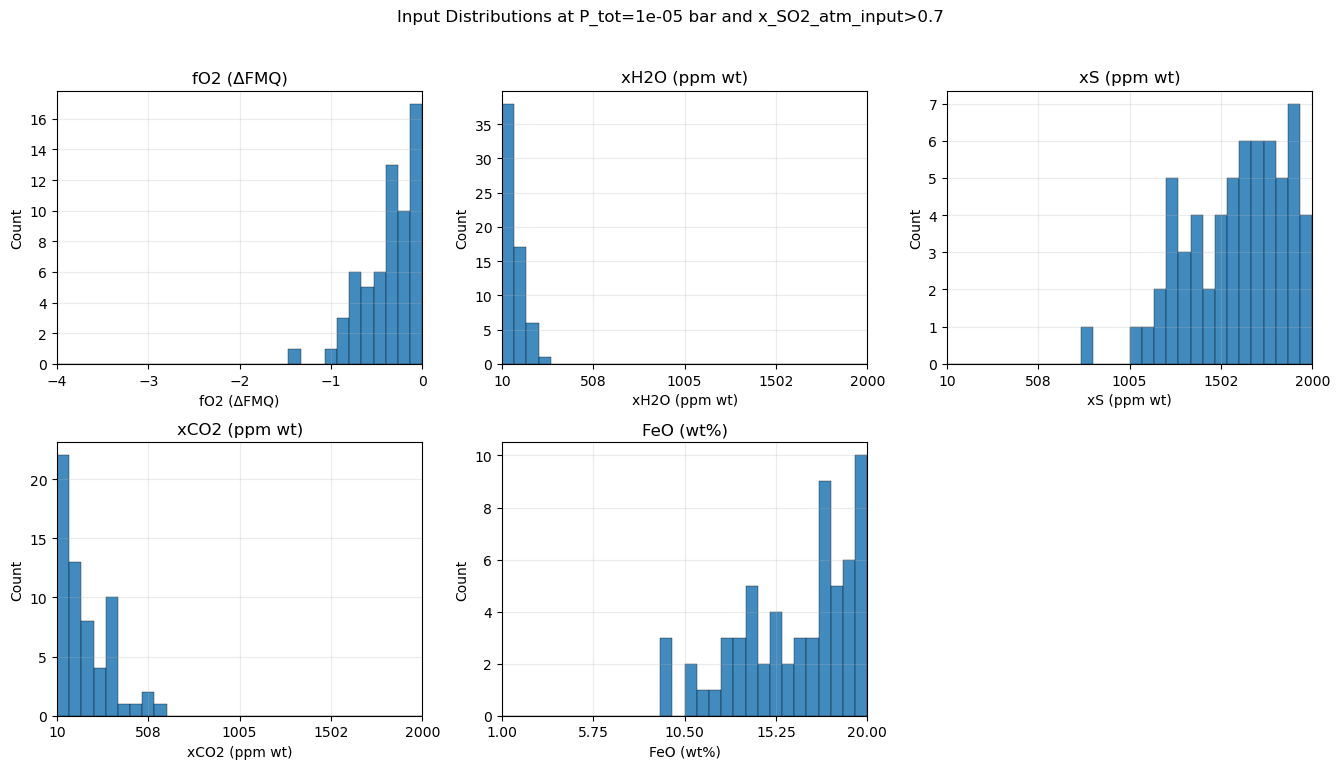

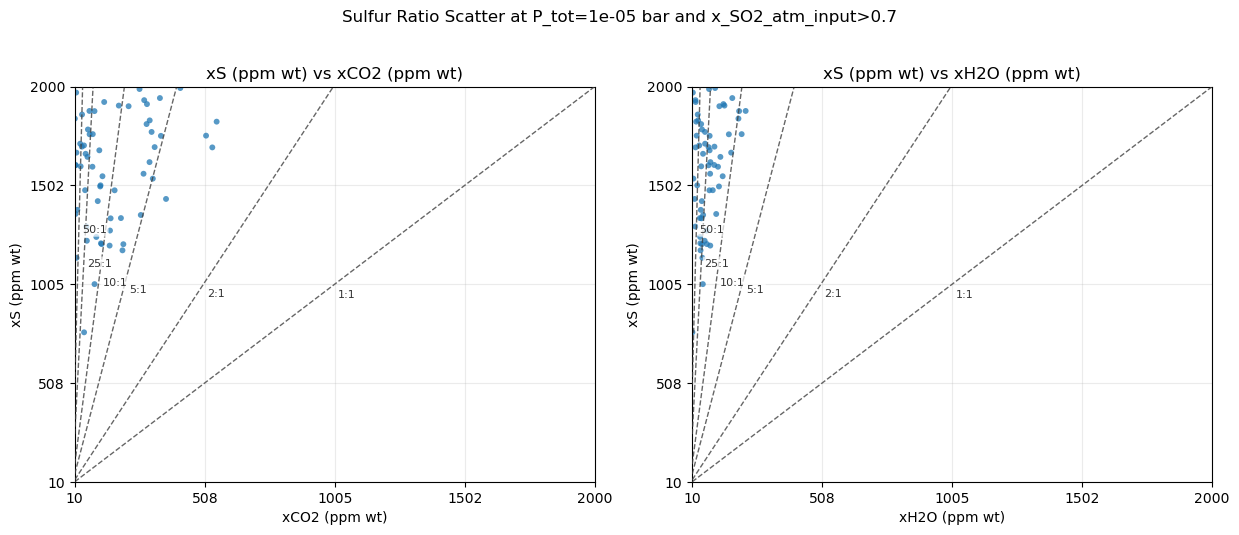

Selected 2 rows at P_tot=0.1 bar (±1e-07) with x_SO2_atm_input>0.7


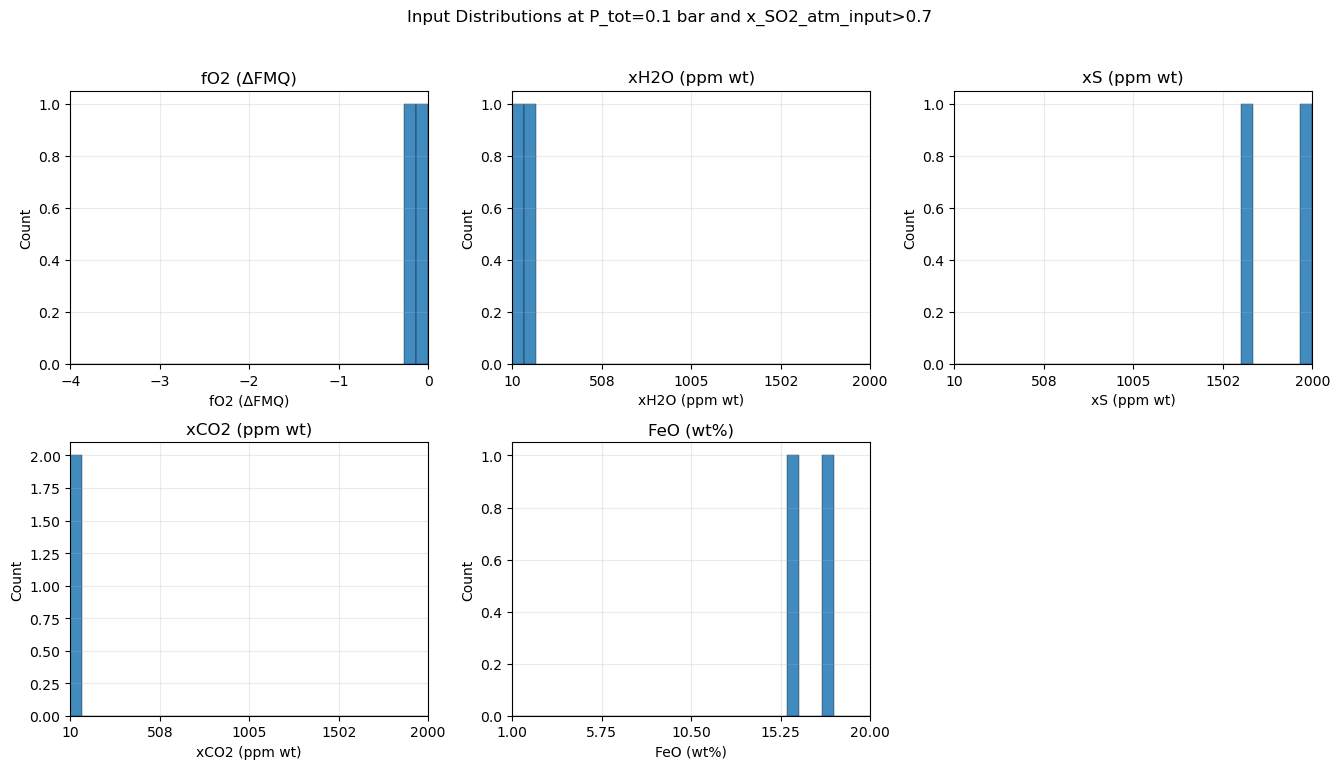

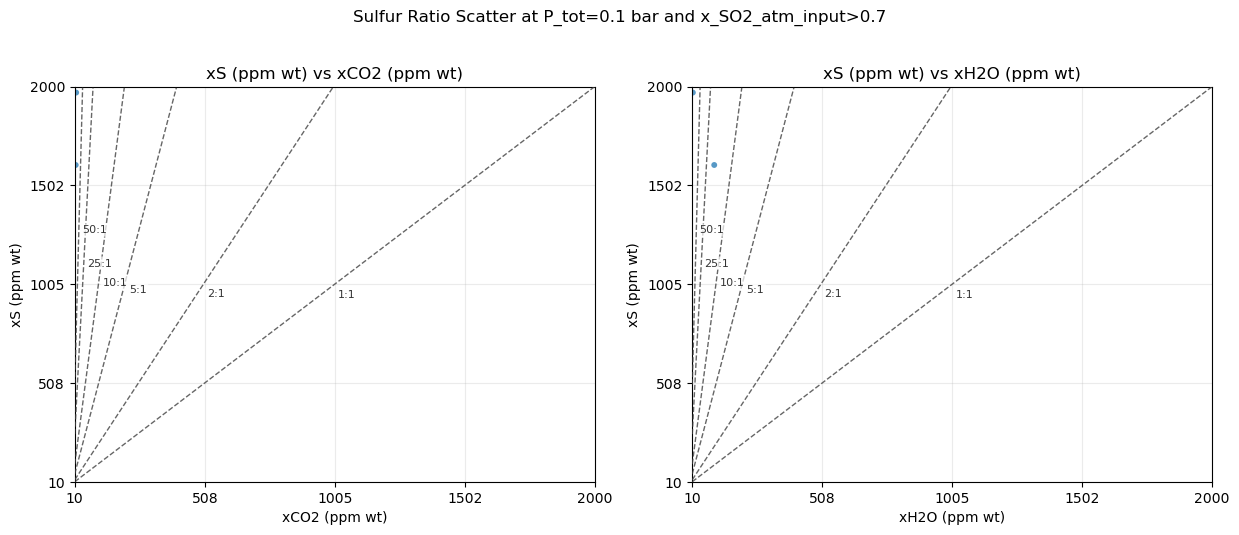

In [54]:
# Function: plot one pressure slice filtered by SO2 threshold

def plot_slice_diagnostics(pressure_slice=1e-5, so2_threshold=0.5, data=None):
    """Plot input histograms and sulfur-ratio scatter plots for one pressure slice."""
    if data is None:
        if 'df' in globals():
            data = df
        else:
            d = np.load(filename, allow_pickle=False)
            data = pd.DataFrame(d['data'], columns=d['columns'])

    df_plot = data.copy()
    df_plot.columns = [str(c) for c in df_plot.columns]

    pressure_col = next((c for c in ['P_tot', 'P'] if c in df_plot.columns), None)
    so2_col = next((c for c in ['x_SO2_atm_input', 'x_SO2_gas', 'x_SO2'] if c in df_plot.columns), None)

    required_cols = ['FMQ_sat', 'mH2O_sat', 'mS_sat', 'mCO2_sat', 'FeO_star_wt']
    missing = [c for c in required_cols if c not in df_plot.columns]
    if pressure_col is None:
        raise KeyError(f"Could not find pressure column. Available columns: {list(df_plot.columns)}")
    if so2_col is None:
        raise KeyError(f"Could not find SO2 mixing-ratio column. Available columns: {list(df_plot.columns)}")
    if missing:
        raise KeyError(f"Missing required input columns: {missing}")

    def _norm_bounds(bounds):
        b = np.asarray(bounds, dtype=float).ravel()
        if b.size < 2:
            raise ValueError(f'Expected 2-value bounds, got {bounds}')
        lo, hi = float(b[0]), float(b[1])
        return (lo, hi) if lo <= hi else (hi, lo)

    sample_bounds = {
        'FMQ_sat': _norm_bounds(globals().get('FMQ_sat_range', (-4.0, 0.0))),
        'mH2O_sat': _norm_bounds(globals().get('m_H2O_sat_range', np.array([10.0, 1000.0]) * 1e-6)),
        'mS_sat': _norm_bounds(globals().get('m_S_sat_range', np.array([10.0, 1000.0]) * 1e-6)),
        'mCO2_sat': _norm_bounds(globals().get('m_CO2_sat_range', np.array([10.0, 1000.0]) * 1e-6)),
        'FeO_star_wt': _norm_bounds(globals().get('FeO_star_wt_range', np.array([1.0, 20.0]) * 1e-2)),
    }

    num_cols = required_cols + [pressure_col, so2_col]
    for c in num_cols:
        df_plot[c] = pd.to_numeric(df_plot[c], errors='coerce')

    finite_mask = np.isfinite(df_plot[num_cols]).all(axis=1)
    pressure_atol = max(1e-12, abs(pressure_slice) * 1e-6)
    sel_mask = (
        finite_mask
        & np.isclose(df_plot[pressure_col].to_numpy(dtype=float), pressure_slice, rtol=0.0, atol=pressure_atol)
        & (df_plot[so2_col] > so2_threshold)
    )
    sel = df_plot.loc[sel_mask].copy()

    if sel.empty:
        raise ValueError(
            f'No rows found at {pressure_col}={pressure_slice:g} bar (±{pressure_atol:g}) '
            f'with {so2_col} > {so2_threshold}.'
        )

    print(
        f'Selected {len(sel)} rows at {pressure_col}={pressure_slice:g} bar (±{pressure_atol:g}) '
        f'with {so2_col}>{so2_threshold}'
    )

    # Histograms of inputs (bounds fixed to sampling ranges)
    hist_specs = [
        ('FMQ_sat', 'fO2 (ΔFMQ)', 1.0),
        ('mH2O_sat', 'xH2O (ppm wt)', 1e6),
        ('mS_sat', 'xS (ppm wt)', 1e6),
        ('mCO2_sat', 'xCO2 (ppm wt)', 1e6),
        ('FeO_star_wt', 'FeO (wt%)', 100.0),
    ]

    fig, axes = plt.subplots(2, 3, figsize=(13.5, 7.5))
    axes = np.atleast_1d(axes).ravel()

    for i, (col, xlabel, scale) in enumerate(hist_specs):
        ax = axes[i]
        lo, hi = sample_bounds[col]
        lo_u, hi_u = lo * scale, hi * scale
        bins = np.linspace(lo_u, hi_u, 31)

        vals = sel[col].to_numpy(dtype=float) * scale
        vals = vals[np.isfinite(vals)]
        ax.hist(vals, bins=bins, color='tab:blue', alpha=0.85, edgecolor='black', linewidth=0.3)

        ax.set_xlim(lo_u, hi_u)
        ax.set_xticks(np.linspace(lo_u, hi_u, 5))
        ax.set_xlabel(xlabel)
        ax.set_ylabel('Count')
        ax.set_title(xlabel)
        ax.grid(alpha=0.25)

    for j in range(len(hist_specs), len(axes)):
        axes[j].axis('off')

    fig.suptitle(
        f'Input Distributions at {pressure_col}={pressure_slice:g} bar and {so2_col}>{so2_threshold}',
        y=1.02,
    )
    plt.tight_layout()
    plt.show()

    # Volatile-ratio scatter plots (sulfur-focused), with ratio guides
    ratio_pairs = [
        ('mCO2_sat', 'mS_sat', 'xCO2 (ppm wt)', 'xS (ppm wt)'),
        ('mH2O_sat', 'mS_sat', 'xH2O (ppm wt)', 'xS (ppm wt)'),
    ]
    ratio_levels = [1, 2, 5, 10, 25, 50]

    fig, axes = plt.subplots(1, 2, figsize=(12.5, 5.2))
    axes = np.atleast_1d(axes)

    for ax, (xcol, ycol, xlabel, ylabel) in zip(axes, ratio_pairs):
        xlo, xhi = sample_bounds[xcol]
        ylo, yhi = sample_bounds[ycol]
        xlo_u, xhi_u = xlo * 1e6, xhi * 1e6
        ylo_u, yhi_u = ylo * 1e6, yhi * 1e6

        x = sel[xcol].to_numpy(dtype=float) * 1e6
        y = sel[ycol].to_numpy(dtype=float) * 1e6
        m = np.isfinite(x) & np.isfinite(y)
        ax.scatter(x[m], y[m], s=18, alpha=0.75, color='tab:blue', edgecolors='none', rasterized=True, zorder=2)

        x_line = np.linspace(xlo_u, xhi_u, 600)
        for r in ratio_levels:
            y_line = r * x_line
            vis = (y_line >= ylo_u) & (y_line <= yhi_u)
            if not np.any(vis):
                continue
            ax.plot(x_line[vis], y_line[vis], '--', color='0.25', linewidth=1.0, alpha=0.8, zorder=4)
            vis_idx = np.where(vis)[0]
            i_label = vis_idx[len(vis_idx) // 2]
            ax.annotate(
                f'{r}:1',
                (x_line[i_label], y_line[i_label]),
                xytext=(2, -4),
                textcoords='offset points',
                fontsize=8,
                color='0.2',
                ha='left',
                va='top',
                clip_on=True,
                zorder=5,
                bbox=dict(boxstyle='round,pad=0.15', facecolor='white', edgecolor='none', alpha=0.7),
            )

        ax.set_xlim(xlo_u, xhi_u)
        ax.set_ylim(ylo_u, yhi_u)
        ax.set_xticks(np.linspace(xlo_u, xhi_u, 5))
        ax.set_yticks(np.linspace(ylo_u, yhi_u, 5))
        ax.set_xlabel(xlabel)
        ax.set_ylabel(ylabel)
        ax.set_title(f'{ylabel} vs {xlabel}')
        ax.grid(alpha=0.25)

    fig.suptitle(
        f'Sulfur Ratio Scatter at {pressure_col}={pressure_slice:g} bar and {so2_col}>{so2_threshold}',
        y=1.02,
    )
    plt.tight_layout()
    plt.show()

    return sel


# Example call
selected_slice_df = plot_slice_diagnostics(pressure_slice=1e-5, so2_threshold=0.7)
selected_slice_df = plot_slice_diagnostics(pressure_slice=1e-1, so2_threshold=0.7)

